In [1]:
import sys
import torch

print("Python:")
print(sys.executable)

print("\nPyTorch:")
print(torch.__version__)

print("\nCUDA available:")
print(torch.cuda.is_available())

print("\nGPU:")
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE")

Python:
c:\Projects\CycleGAN\.venv\Scripts\python.exe

PyTorch:
2.13.0+cu132

CUDA available:
True

GPU:
NVIDIA GeForce RTX 4090


Imports

In [2]:
import os
import sys
import random
import time
import json
import math
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.utils import make_grid, save_image

from tqdm.auto import tqdm

print("All imports successful.")

All imports successful.


Environment + reproducibility

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Good performance setting for RTX 4090
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print("=" * 60)
print("ENVIRONMENT")
print("=" * 60)

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA runtime:", torch.version.cuda)
    print(
        "VRAM:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

ENVIRONMENT
Python: c:\Projects\CycleGAN\.venv\Scripts\python.exe
PyTorch: 2.13.0+cu132
Torchvision: 0.28.0+cu132
Device: cuda
GPU: NVIDIA GeForce RTX 4090
CUDA runtime: 13.2
VRAM: 23.99 GB


Configuration

In [4]:
# ============================================================
# PROJECT CONFIGURATION
# ============================================================

PROJECT_ROOT = Path(
    r"."
)

DATA_ROOT = PROJECT_ROOT / "dataset" / "dataset"

MONET_DIR = DATA_ROOT / "monet_jpg"
PHOTO_DIR = DATA_ROOT / "photo_jpg"

# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------

OUTPUT_DIR = PROJECT_ROOT / "outputs"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

SAMPLE_DIR = OUTPUT_DIR / "samples"
PLOT_DIR = OUTPUT_DIR / "plots"

PRED_A2B_DIR = OUTPUT_DIR / "pred_A2B"
PRED_B2A_DIR = OUTPUT_DIR / "pred_B2A"

for directory in [
    OUTPUT_DIR,
    CHECKPOINT_DIR,
    SAMPLE_DIR,
    PLOT_DIR,
    PRED_A2B_DIR,
    PRED_B2A_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Domain definitions
# ------------------------------------------------------------

# A = Monet
# B = Photo
#
# G_A2B = Monet -> Photo
# G_B2A = Photo -> Monet

DOMAIN_A = "Monet"
DOMAIN_B = "Photo"

# ------------------------------------------------------------
# Image settings
# ------------------------------------------------------------

IMAGE_SIZE = 256
RESIZE_SIZE = 286

BATCH_SIZE = 4
NUM_WORKERS = 0       # safest for Windows/Jupyter initially

# ------------------------------------------------------------
# CycleGAN hyperparameters
# ------------------------------------------------------------

LEARNING_RATE = 2e-4

BETA1 = 0.5
BETA2 = 0.999

LAMBDA_CYCLE = 10.0
LAMBDA_IDENTITY = 5.0

NUM_RESIDUAL_BLOCKS = 9

print("Project root:", PROJECT_ROOT)
print("Dataset root:", DATA_ROOT)
print("Configuration loaded.")

Project root: .
Dataset root: .\dataset\dataset
Configuration loaded.


Verify dataset

In [5]:
assert DATA_ROOT.exists(), f"Missing dataset: {DATA_ROOT}"
assert MONET_DIR.exists(), f"Missing Monet directory: {MONET_DIR}"
assert PHOTO_DIR.exists(), f"Missing Photo directory: {PHOTO_DIR}"

monet_paths = sorted(MONET_DIR.glob("*.jpg"))
photo_paths = sorted(PHOTO_DIR.glob("*.jpg"))

print("=" * 60)
print("DATASET")
print("=" * 60)

print("Monet images :", len(monet_paths))
print("Photo images :", len(photo_paths))
print("Total images :", len(monet_paths) + len(photo_paths))

assert len(monet_paths) > 0
assert len(photo_paths) > 0

print("\nDataset successfully located.")

DATASET
Monet images : 300
Photo images : 7038
Total images : 7338

Dataset successfully located.


Check the entire dataset for corrupt images

In [6]:
def verify_images(paths, domain_name):
    corrupted = []

    for path in tqdm(paths, desc=f"Checking {domain_name}"):
        try:
            with Image.open(path) as img:
                img.verify()
        except Exception as e:
            corrupted.append((path, str(e)))

    print(f"\n{domain_name}")
    print("Total:", len(paths))
    print("Corrupted:", len(corrupted))

    return corrupted


corrupt_monet = verify_images(monet_paths, "Monet")
corrupt_photo = verify_images(photo_paths, "Photo")

Checking Monet:   0%|          | 0/300 [00:00<?, ?it/s]


Monet
Total: 300
Corrupted: 0


Checking Photo:   0%|          | 0/7038 [00:00<?, ?it/s]


Photo
Total: 7038
Corrupted: 0


Analyze image dimensions

In [7]:
def analyze_images(paths, name):
    dimensions = Counter()
    modes = Counter()

    for path in tqdm(paths, desc=f"Analyzing {name}"):
        with Image.open(path) as img:
            dimensions[img.size] += 1
            modes[img.mode] += 1

    print("\n" + "=" * 60)
    print(name.upper())
    print("=" * 60)

    print("Number of images:", len(paths))
    print("Image modes:", modes)

    print("\nMost common dimensions:")

    for dimensions_value, count in dimensions.most_common(10):
        print(dimensions_value, ":", count)

    return dimensions, modes


monet_dimensions, monet_modes = analyze_images(
    monet_paths,
    "Monet"
)

photo_dimensions, photo_modes = analyze_images(
    photo_paths,
    "Photo"
)

Analyzing Monet:   0%|          | 0/300 [00:00<?, ?it/s]


MONET
Number of images: 300
Image modes: Counter({'RGB': 300})

Most common dimensions:
(256, 256) : 300


Analyzing Photo:   0%|          | 0/7038 [00:00<?, ?it/s]


PHOTO
Number of images: 7038
Image modes: Counter({'RGB': 7038})

Most common dimensions:
(256, 256) : 7038


Show raw images

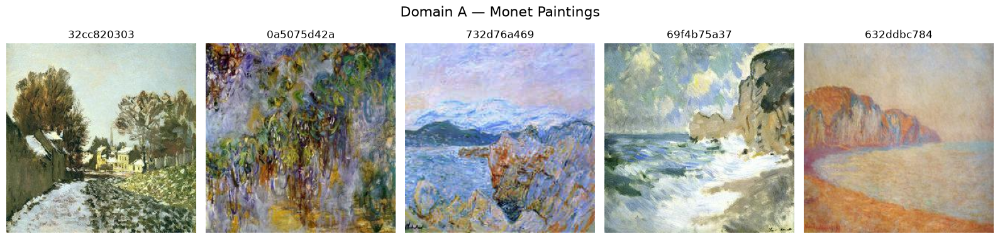

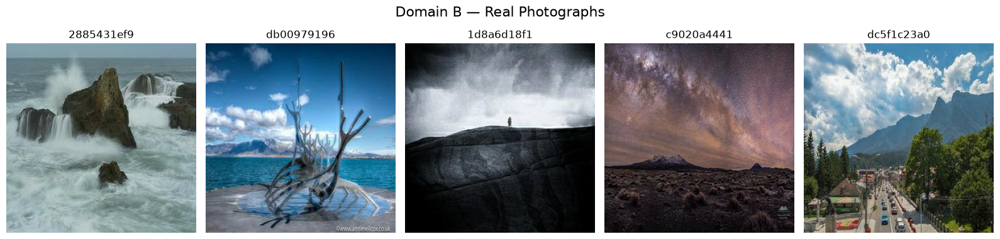

In [8]:
def show_samples(paths, title, n=5):
    selected = random.sample(paths, min(n, len(paths)))

    fig, axes = plt.subplots(
        1,
        len(selected),
        figsize=(16, 4)
    )

    if len(selected) == 1:
        axes = [axes]

    for ax, path in zip(axes, selected):

        with Image.open(path) as img:
            ax.imshow(img.convert("RGB"))

        ax.set_title(path.name[:10])
        ax.axis("off")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


show_samples(
    monet_paths,
    "Domain A — Monet Paintings"
)

show_samples(
    photo_paths,
    "Domain B — Real Photographs"
)

Create deterministic train/evaluation split

In [9]:
def split_dataset(paths, val_fraction=0.10, seed=42):

    paths = list(paths)

    rng = random.Random(seed)
    rng.shuffle(paths)

    val_count = max(
        1,
        int(len(paths) * val_fraction)
    )

    val_paths = paths[:val_count]
    train_paths = paths[val_count:]

    return train_paths, val_paths


monet_train, monet_val = split_dataset(
    monet_paths,
    val_fraction=0.10,
    seed=SEED
)

photo_train, photo_val = split_dataset(
    photo_paths,
    val_fraction=0.10,
    seed=SEED
)


print("=" * 60)
print("TRAIN / VALIDATION SPLIT")
print("=" * 60)

print("\nMONET")
print("Train:", len(monet_train))
print("Validation:", len(monet_val))

print("\nPHOTO")
print("Train:", len(photo_train))
print("Validation:", len(photo_val))

TRAIN / VALIDATION SPLIT

MONET
Train: 270
Validation: 30

PHOTO
Train: 6335
Validation: 703


Save the split

In [10]:
split_data = {
    "seed": SEED,

    "monet_train": [
        path.name for path in monet_train
    ],

    "monet_validation": [
        path.name for path in monet_val
    ],

    "photo_train": [
        path.name for path in photo_train
    ],

    "photo_validation": [
        path.name for path in photo_val
    ]
}

split_file = PROJECT_ROOT / "dataset_split.json"

with open(split_file, "w") as f:
    json.dump(split_data, f, indent=2)

print("Saved:")
print(split_file)

Saved:
.\dataset_split.json


Image transformations

In [11]:
train_transform = transforms.Compose([

    transforms.Resize(
        (RESIZE_SIZE, RESIZE_SIZE),
        interpolation=transforms.InterpolationMode.BICUBIC
    ),

    transforms.RandomCrop(
        IMAGE_SIZE
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])


eval_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=transforms.InterpolationMode.BICUBIC
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])


print("Training transforms:")
print(train_transform)

print("\nEvaluation transforms:")
print(eval_transform)

Training transforms:
Compose(
    Resize(size=(286, 286), interpolation=bicubic, max_size=None, antialias=True)
    RandomCrop(size=(256, 256), padding=None)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)

Evaluation transforms:
Compose(
    Resize(size=(256, 256), interpolation=bicubic, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)


Unpaired dataset

In [12]:
class UnpairedImageDataset(Dataset):

    def __init__(
        self,
        domain_a_paths,
        domain_b_paths,
        transform=None
    ):

        self.domain_a_paths = list(domain_a_paths)
        self.domain_b_paths = list(domain_b_paths)

        self.transform = transform

        self.length = max(
            len(self.domain_a_paths),
            len(self.domain_b_paths)
        )


    def __len__(self):
        return self.length


    def __getitem__(self, index):

        # ----------------------------------------------------
        # Domain A: Monet
        # ----------------------------------------------------

        a_path = self.domain_a_paths[
            index % len(self.domain_a_paths)
        ]

        # ----------------------------------------------------
        # Domain B: Photo
        #
        # Independently sampled because CycleGAN uses
        # UNPAIRED training.
        # ----------------------------------------------------

        b_path = random.choice(
            self.domain_b_paths
        )

        with Image.open(a_path) as image_a:
            image_a = image_a.convert("RGB")

        with Image.open(b_path) as image_b:
            image_b = image_b.convert("RGB")

        if self.transform is not None:

            image_a = self.transform(image_a)
            image_b = self.transform(image_b)

        return {
            "A": image_a,
            "B": image_b,
            "A_path": str(a_path),
            "B_path": str(b_path)
        }

Create training dataset

In [13]:
train_dataset = UnpairedImageDataset(
    domain_a_paths=monet_train,
    domain_b_paths=photo_train,
    transform=train_transform
)

print("Dataset length:", len(train_dataset))

Dataset length: 6335


DataLoader

In [14]:
train_loader = DataLoader(
    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    drop_last=True
)

print("Training batches:", len(train_loader))

Training batches: 1583


#### Num workers define

In [15]:
NUM_WORKERS = 4

Test a batch

In [16]:
batch = next(iter(train_loader))

real_A = batch["A"]
real_B = batch["B"]

print("=" * 60)
print("BATCH TEST")
print("=" * 60)

print("\nDomain A — Monet")
print("Shape:", real_A.shape)
print("dtype:", real_A.dtype)
print("Min:", real_A.min().item())
print("Max:", real_A.max().item())

print("\nDomain B — Photo")
print("Shape:", real_B.shape)
print("dtype:", real_B.dtype)
print("Min:", real_B.min().item())
print("Max:", real_B.max().item())

BATCH TEST

Domain A — Monet
Shape: torch.Size([4, 3, 256, 256])
dtype: torch.float32
Min: -1.0
Max: 1.0

Domain B — Photo
Shape: torch.Size([4, 3, 256, 256])
dtype: torch.float32
Min: -1.0
Max: 1.0


Visualize transformed batches

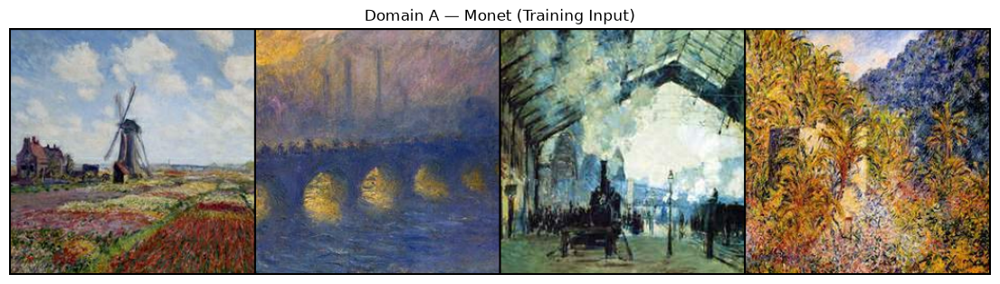

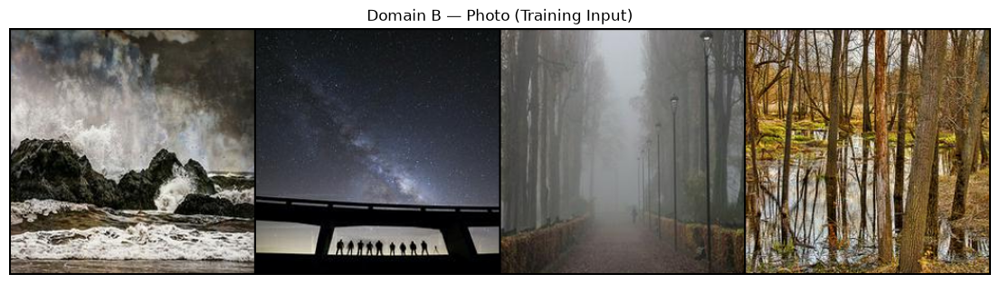

In [17]:
def denormalize(x):
    return (x * 0.5) + 0.5


def display_batch(images, title, n=4):

    images = images[:n].detach().cpu()

    images = denormalize(images)

    images = torch.clamp(
        images,
        0,
        1
    )

    grid = make_grid(
        images,
        nrow=n,
        padding=2
    )

    plt.figure(figsize=(14, 4))

    plt.imshow(
        grid.permute(1, 2, 0)
    )

    plt.title(title)
    plt.axis("off")

    plt.show()


display_batch(
    real_A,
    "Domain A — Monet (Training Input)"
)

display_batch(
    real_B,
    "Domain B — Photo (Training Input)"
)

Weight initialization

In [18]:
def init_weights(model):

    for module in model.modules():

        if isinstance(
            module,
            (nn.Conv2d, nn.ConvTranspose2d)
        ):
            nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02
            )

            if module.bias is not None:
                nn.init.constant_(
                    module.bias,
                    0.0
                )

        elif isinstance(module, nn.InstanceNorm2d):

            if module.weight is not None:
                nn.init.normal_(
                    module.weight,
                    mean=1.0,
                    std=0.02
                )

            if module.bias is not None:
                nn.init.constant_(
                    module.bias,
                    0.0
                )

Residual Block

In [19]:
class ResidualBlock(nn.Module):

    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(

            nn.ReflectionPad2d(1),

            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                stride=1,
                padding=0,
                bias=False
            ),

            nn.InstanceNorm2d(channels),

            nn.ReLU(inplace=True),

            nn.ReflectionPad2d(1),

            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                stride=1,
                padding=0,
                bias=False
            ),

            nn.InstanceNorm2d(channels)
        )


    def forward(self, x):

        return x + self.block(x)

ResNet Generator

In [20]:
class ResNetGenerator(nn.Module):

    def __init__(
        self,
        input_channels=3,
        output_channels=3,
        num_residual_blocks=9
    ):

        super().__init__()

        layers = []

        # ====================================================
        # Initial convolution
        # 3 x 256 x 256
        # ->
        # 64 x 256 x 256
        # ====================================================

        layers += [

            nn.ReflectionPad2d(3),

            nn.Conv2d(
                input_channels,
                64,
                kernel_size=7,
                stride=1,
                padding=0,
                bias=False
            ),

            nn.InstanceNorm2d(64),

            nn.ReLU(inplace=True)
        ]


        # ====================================================
        # Downsampling
        #
        # 64 x 256 x 256
        # ->
        # 128 x 128 x 128
        # ->
        # 256 x 64 x 64
        # ====================================================

        in_channels = 64

        for _ in range(2):

            out_channels = in_channels * 2

            layers += [

                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    bias=False
                ),

                nn.InstanceNorm2d(out_channels),

                nn.ReLU(inplace=True)
            ]

            in_channels = out_channels


        # ====================================================
        # Residual blocks
        # ====================================================

        for _ in range(num_residual_blocks):

            layers.append(
                ResidualBlock(in_channels)
            )


        # ====================================================
        # Upsampling
        #
        # 256 x 64 x 64
        # ->
        # 128 x 128 x 128
        # ->
        # 64 x 256 x 256
        # ====================================================

        for _ in range(2):

            out_channels = in_channels // 2

            layers += [

                nn.ConvTranspose2d(
                    in_channels,
                    out_channels,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    output_padding=1,
                    bias=False
                ),

                nn.InstanceNorm2d(out_channels),

                nn.ReLU(inplace=True)
            ]

            in_channels = out_channels


        # ====================================================
        # Output
        # ====================================================

        layers += [

            nn.ReflectionPad2d(3),

            nn.Conv2d(
                64,
                output_channels,
                kernel_size=7,
                stride=1,
                padding=0
            ),

            nn.Tanh()
        ]


        self.model = nn.Sequential(*layers)


    def forward(self, x):

        return self.model(x)

PatchGAN Discriminator

In [21]:
class PatchGANDiscriminator(nn.Module):

    def __init__(self, input_channels=3):

        super().__init__()


        def discriminator_block(
            in_channels,
            out_channels,
            stride,
            normalize=True
        ):

            layers = [

                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=4,
                    stride=stride,
                    padding=1
                )
            ]

            if normalize:

                layers.append(
                    nn.InstanceNorm2d(
                        out_channels
                    )
                )

            layers.append(
                nn.LeakyReLU(
                    0.2,
                    inplace=True
                )
            )

            return layers


        self.model = nn.Sequential(

            *discriminator_block(
                3,
                64,
                stride=2,
                normalize=False
            ),

            *discriminator_block(
                64,
                128,
                stride=2
            ),

            *discriminator_block(
                128,
                256,
                stride=2
            ),

            *discriminator_block(
                256,
                512,
                stride=1
            ),

            nn.Conv2d(
                512,
                1,
                kernel_size=4,
                stride=1,
                padding=1
            )
        )


    def forward(self, x):

        return self.model(x)

We're going to use least-squares GAN loss:

In [22]:
nn.MSELoss()

MSELoss()

Create all four networks

In [23]:
G_A2B = ResNetGenerator(
    num_residual_blocks=NUM_RESIDUAL_BLOCKS
).to(device)

G_B2A = ResNetGenerator(
    num_residual_blocks=NUM_RESIDUAL_BLOCKS
).to(device)

D_A = PatchGANDiscriminator().to(device)

D_B = PatchGANDiscriminator().to(device)


# Initialize weights

G_A2B.apply(init_weights)
G_B2A.apply(init_weights)

D_A.apply(init_weights)
D_B.apply(init_weights)


print("Networks created successfully.")

Networks created successfully.


Parameter counts

In [24]:
def count_parameters(model):

    total = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    return total, trainable


models = {
    "G_A2B": G_A2B,
    "G_B2A": G_B2A,
    "D_A": D_A,
    "D_B": D_B
}


parameter_data = []


for name, model in models.items():

    total, trainable = count_parameters(model)

    parameter_data.append({
        "Model": name,
        "Total Parameters": total,
        "Trainable Parameters": trainable
    })


parameter_df = pd.DataFrame(parameter_data)

display(parameter_df)


total_cyclegan_parameters = sum(
    count_parameters(model)[0]
    for model in models.values()
)


print(
    "\nTotal CycleGAN parameters:",
    f"{total_cyclegan_parameters:,}"
)

,Model,Total Parameters,Trainable Parameters
0,G_A2B,11372931,11372931
1,G_B2A,11372931,11372931
2,D_A,2764737,2764737
3,D_B,2764737,2764737



Total CycleGAN parameters: 28,275,336


Save the parameters

In [25]:
parameter_df.to_csv(
    OUTPUT_DIR / "parameter_counts.csv",
    index=False
)

Test generator forward passes

In [26]:
G_A2B.eval()
G_B2A.eval()

with torch.no_grad():

    test_A = real_A.to(
        device,
        non_blocking=True
    )

    test_B = real_B.to(
        device,
        non_blocking=True
    )


    fake_B = G_A2B(test_A)

    fake_A = G_B2A(test_B)


print("Input Monet:")
print(test_A.shape)

print("\nGenerated Photo:")
print(fake_B.shape)


print("\nInput Photo:")
print(test_B.shape)

print("\nGenerated Monet:")
print(fake_A.shape)


print("\nGenerated Photo range:")
print(
    fake_B.min().item(),
    fake_B.max().item()
)

print("\nGenerated Monet range:")
print(
    fake_A.min().item(),
    fake_A.max().item()
)

Input Monet:
torch.Size([4, 3, 256, 256])

Generated Photo:
torch.Size([4, 3, 256, 256])

Input Photo:
torch.Size([4, 3, 256, 256])

Generated Monet:
torch.Size([4, 3, 256, 256])

Generated Photo range:
-0.9999921917915344 0.9996846914291382

Generated Monet range:
-0.9999997019767761 0.999991774559021


Test cycle reconstruction

In [27]:
with torch.no_grad():

    # Monet
    # ->
    # fake Photo
    # ->
    # reconstructed Monet

    fake_B = G_A2B(test_A)

    reconstructed_A = G_B2A(
        fake_B
    )


    # Photo
    # ->
    # fake Monet
    # ->
    # reconstructed Photo

    fake_A = G_B2A(test_B)

    reconstructed_B = G_A2B(
        fake_A
    )


print("A:")
print(test_A.shape)

print("A -> B:")
print(fake_B.shape)

print("A -> B -> A:")
print(reconstructed_A.shape)


print("\nB:")
print(test_B.shape)

print("B -> A:")
print(fake_A.shape)

print("B -> A -> B:")
print(reconstructed_B.shape)

A:
torch.Size([4, 3, 256, 256])
A -> B:
torch.Size([4, 3, 256, 256])
A -> B -> A:
torch.Size([4, 3, 256, 256])

B:
torch.Size([4, 3, 256, 256])
B -> A:
torch.Size([4, 3, 256, 256])
B -> A -> B:
torch.Size([4, 3, 256, 256])


Test discriminators

In [28]:
D_A.eval()
D_B.eval()


with torch.no_grad():

    pred_real_A = D_A(test_A)

    pred_fake_A = D_A(fake_A)


    pred_real_B = D_B(test_B)

    pred_fake_B = D_B(fake_B)


print("D_A real output:")
print(pred_real_A.shape)

print("\nD_A fake output:")
print(pred_fake_A.shape)


print("\nD_B real output:")
print(pred_real_B.shape)

print("\nD_B fake output:")
print(pred_fake_B.shape)

D_A real output:
torch.Size([4, 1, 30, 30])

D_A fake output:
torch.Size([4, 1, 30, 30])

D_B real output:
torch.Size([4, 1, 30, 30])

D_B fake output:
torch.Size([4, 1, 30, 30])


Visual architecture sanity check

In [29]:
print("=" * 60)
print("GENERATOR")
print("=" * 60)

print(G_A2B)

print("\n" + "=" * 60)
print("DISCRIMINATOR")
print("=" * 60)

print(D_A)

GENERATOR
ResNetGenerator(
  (model): Sequential(
    (0): ReflectionPad2d((3, 3, 3, 3))
    (1): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (2): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=False)
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (5): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=False)
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (8): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, bias=False, track_running_stats=False)
    (9): ReLU(inplace=True)
    (10): ResidualBlock(
      (block): Sequential(
        (0): ReflectionPad2d((1, 1, 1, 1))
        (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
        (2): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, bias=False, trac

Loss functions

In [30]:
# Least-Squares GAN loss
criterion_GAN = nn.MSELoss()

# Cycle-consistency loss
criterion_cycle = nn.L1Loss()

# Identity loss
criterion_identity = nn.L1Loss()


print("Loss functions created.")

print("Adversarial:", criterion_GAN)
print("Cycle:", criterion_cycle)
print("Identity:", criterion_identity)

Loss functions created.
Adversarial: MSELoss()
Cycle: L1Loss()
Identity: L1Loss()


Cycle consistency

In [31]:
LAMBDA_CYCLE = 10

In [32]:
LAMBDA_IDENTITY = 5

Return networks to training mode

In [33]:
G_A2B.train()
G_B2A.train()
D_A.train()
D_B.train()

print("All networks set to training mode.")

All networks set to training mode.


### Optimizers

CycleGAN jointly optimizes both generators, while the discriminators have their own optimizers.

In [34]:
optimizer_G = optim.Adam(
    list(G_A2B.parameters()) +
    list(G_B2A.parameters()),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2)
)

optimizer_D_A = optim.Adam(
    D_A.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2)
)

optimizer_D_B = optim.Adam(
    D_B.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2)
)

print("Optimizers created.")
print("Learning rate:", LEARNING_RATE)
print("Betas:", (BETA1, BETA2))

Optimizers created.
Learning rate: 0.0002
Betas: (0.5, 0.999)


Image replay buffer

In [35]:
class ImagePool:

    def __init__(self, pool_size=50):
        self.pool_size = pool_size
        self.images = []


    @torch.no_grad()
    def query(self, images):

        if self.pool_size == 0:
            return images

        returned_images = []

        for image in images:

            image = image.unsqueeze(0)

            if len(self.images) < self.pool_size:

                self.images.append(
                    image.detach().clone()
                )

                returned_images.append(image)

            else:

                if random.random() > 0.5:

                    index = random.randint(
                        0,
                        self.pool_size - 1
                    )

                    old_image = self.images[index].clone()

                    self.images[index] = (
                        image.detach().clone()
                    )

                    returned_images.append(old_image)

                else:

                    returned_images.append(image)

        return torch.cat(
            returned_images,
            dim=0
        )


fake_A_pool = ImagePool(pool_size=50)
fake_B_pool = ImagePool(pool_size=50)

print("Replay buffers created.")

Replay buffers created.


Gradient norm function

In [36]:
def get_gradient_norm(model):

    total_norm_squared = 0.0

    for parameter in model.parameters():

        if parameter.grad is not None:

            grad = parameter.grad.detach()

            norm = grad.norm(2).item()

            total_norm_squared += norm ** 2

    return total_norm_squared ** 0.5

NaN/Inf checker

In [37]:
def count_invalid_values(models):

    count = 0

    for model in models:

        for parameter in model.parameters():

            if torch.isnan(parameter).any():
                count += torch.isnan(parameter).sum().item()

            if torch.isinf(parameter).any():
                count += torch.isinf(parameter).sum().item()

    return int(count)

Learning-rate scheduler

first half       constant LR
second half      linearly decay LR → 0

In [38]:
TOTAL_EPOCHS = 200
DECAY_START_EPOCH = 100


def lambda_rule(epoch):

    if epoch < DECAY_START_EPOCH:
        return 1.0

    return 1.0 - (
        (epoch - DECAY_START_EPOCH)
        / (TOTAL_EPOCHS - DECAY_START_EPOCH)
    )


scheduler_G = optim.lr_scheduler.LambdaLR(
    optimizer_G,
    lr_lambda=lambda_rule
)

scheduler_D_A = optim.lr_scheduler.LambdaLR(
    optimizer_D_A,
    lr_lambda=lambda_rule
)

scheduler_D_B = optim.lr_scheduler.LambdaLR(
    optimizer_D_B,
    lr_lambda=lambda_rule
)

print("Schedulers created.")

Schedulers created.


Training history

In [39]:
history = []

print("Training history initialized.")

Training history initialized.


Save sample translations

In [40]:
@torch.no_grad()
def save_training_samples(
    epoch,
    real_A,
    real_B
):

    G_A2B.eval()
    G_B2A.eval()

    sample_A = real_A[:4].to(device)
    sample_B = real_B[:4].to(device)

    fake_B = G_A2B(sample_A)
    fake_A = G_B2A(sample_B)

    rec_A = G_B2A(fake_B)
    rec_B = G_A2B(fake_A)

    # --------------------------------------------------------
    # Monet -> Photo -> Monet
    # --------------------------------------------------------

    grid_A = torch.cat(
        [
            sample_A,
            fake_B,
            rec_A
        ],
        dim=0
    )

    save_image(
        denormalize(grid_A).clamp(0, 1),
        SAMPLE_DIR / f"epoch_{epoch:03d}_A_cycle.jpg",
        nrow=4
    )

    # --------------------------------------------------------
    # Photo -> Monet -> Photo
    # --------------------------------------------------------

    grid_B = torch.cat(
        [
            sample_B,
            fake_A,
            rec_B
        ],
        dim=0
    )

    save_image(
        denormalize(grid_B).clamp(0, 1),
        SAMPLE_DIR / f"epoch_{epoch:03d}_B_cycle.jpg",
        nrow=4
    )

    G_A2B.train()
    G_B2A.train()

Checkpoint function

In [41]:
def save_checkpoint(epoch):

    checkpoint = {

        "epoch": epoch,

        "G_A2B": G_A2B.state_dict(),
        "G_B2A": G_B2A.state_dict(),

        "D_A": D_A.state_dict(),
        "D_B": D_B.state_dict(),

        "optimizer_G": optimizer_G.state_dict(),

        "optimizer_D_A":
            optimizer_D_A.state_dict(),

        "optimizer_D_B":
            optimizer_D_B.state_dict()
    }

    path = (
        CHECKPOINT_DIR /
        f"cyclegan_epoch_{epoch:03d}.pth"
    )

    torch.save(
        checkpoint,
        path
    )

    print("Checkpoint saved:", path)

Test the losses manually

In [42]:
G_A2B.train()
G_B2A.train()
D_A.train()
D_B.train()

real_A_test = real_A.to(device)
real_B_test = real_B.to(device)

# ------------------------------------------------------------
# Translation
# ------------------------------------------------------------

fake_B_test = G_A2B(real_A_test)
fake_A_test = G_B2A(real_B_test)

# ------------------------------------------------------------
# Cycle reconstruction
# ------------------------------------------------------------

rec_A_test = G_B2A(fake_B_test)
rec_B_test = G_A2B(fake_A_test)

# ------------------------------------------------------------
# Identity
# ------------------------------------------------------------

identity_A_test = G_B2A(real_A_test)
identity_B_test = G_A2B(real_B_test)

# ------------------------------------------------------------
# Adversarial
# ------------------------------------------------------------

pred_fake_B = D_B(fake_B_test)
pred_fake_A = D_A(fake_A_test)

loss_G_A2B_adv = criterion_GAN(
    pred_fake_B,
    torch.ones_like(pred_fake_B)
)

loss_G_B2A_adv = criterion_GAN(
    pred_fake_A,
    torch.ones_like(pred_fake_A)
)

# ------------------------------------------------------------
# Cycle
# ------------------------------------------------------------

loss_cycle_A = criterion_cycle(
    rec_A_test,
    real_A_test
)

loss_cycle_B = criterion_cycle(
    rec_B_test,
    real_B_test
)

# ------------------------------------------------------------
# Identity
# ------------------------------------------------------------

loss_identity_A = criterion_identity(
    identity_A_test,
    real_A_test
)

loss_identity_B = criterion_identity(
    identity_B_test,
    real_B_test
)

# ------------------------------------------------------------
# Total generator loss
# ------------------------------------------------------------

loss_G_test = (
    loss_G_A2B_adv
    + loss_G_B2A_adv

    + LAMBDA_CYCLE
      * (loss_cycle_A + loss_cycle_B)

    + LAMBDA_IDENTITY
      * (loss_identity_A + loss_identity_B)
)

print("=" * 60)
print("LOSS SANITY CHECK")
print("=" * 60)

print("G_A2B adversarial :", loss_G_A2B_adv.item())
print("G_B2A adversarial :", loss_G_B2A_adv.item())

print("Cycle A            :", loss_cycle_A.item())
print("Cycle B            :", loss_cycle_B.item())

print("Identity A         :", loss_identity_A.item())
print("Identity B         :", loss_identity_B.item())

print("-" * 60)

print("Total G loss       :", loss_G_test.item())

print("\nFinite:",
      torch.isfinite(loss_G_test).item())

LOSS SANITY CHECK
G_A2B adversarial : 1.3203705549240112
G_B2A adversarial : 2.3560450077056885
Cycle A            : 0.5357426404953003
Cycle B            : 0.5550806522369385
Identity A         : 0.523802638053894
Identity B         : 0.5503131151199341
------------------------------------------------------------
Total G loss       : 19.95522689819336

Finite: True


Clear temporary GPU tensors

In [43]:
del (
    real_A_test,
    real_B_test,
    fake_A_test,
    fake_B_test,
    rec_A_test,
    rec_B_test,
    identity_A_test,
    identity_B_test,
    pred_fake_A,
    pred_fake_B,
    loss_G_test
)

torch.cuda.empty_cache()

print(
    "Allocated GPU memory:",
    round(
        torch.cuda.memory_allocated() / 1024**2,
        2
    ),
    "MB"
)

Allocated GPU memory: 8563.4 MB


AMP configuration

In [44]:
USE_AMP = True

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

print("AMP enabled:", USE_AMP)

AMP enabled: True


Helper: finite gradient check

In [45]:
def gradients_are_finite(model):
    for parameter in model.parameters():
        if parameter.grad is not None:
            if not torch.isfinite(parameter.grad).all():
                return False
    return True

100-step smoke test

In [46]:
# ============================================================
# CycleGAN 100-Step Training Smoke Test
# ============================================================

SMOKE_STEPS = 100

G_A2B.train()
G_B2A.train()
D_A.train()
D_B.train()

# Reset peak-memory statistics
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

smoke_history = []

nan_count = 0

start_time = time.perf_counter()

progress_bar = tqdm(
    enumerate(train_loader),
    total=SMOKE_STEPS,
    desc="CycleGAN smoke test"
)

for step, batch in progress_bar:

    if step >= SMOKE_STEPS:
        break

    # ========================================================
    # Load images
    # ========================================================

    real_A = batch["A"].to(
        device,
        non_blocking=True
    )

    real_B = batch["B"].to(
        device,
        non_blocking=True
    )

    # ========================================================
    # 1. TRAIN GENERATORS
    # ========================================================

    optimizer_G.zero_grad(
        set_to_none=True
    )

    with torch.amp.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=USE_AMP
    ):

        # ----------------------------------------------------
        # Translation
        # ----------------------------------------------------

        fake_B = G_A2B(real_A)
        fake_A = G_B2A(real_B)

        # ----------------------------------------------------
        # Adversarial losses
        # ----------------------------------------------------

        pred_fake_B = D_B(fake_B)

        loss_G_A2B_adv = criterion_GAN(
            pred_fake_B,
            torch.ones_like(pred_fake_B)
        )


        pred_fake_A = D_A(fake_A)

        loss_G_B2A_adv = criterion_GAN(
            pred_fake_A,
            torch.ones_like(pred_fake_A)
        )

        # ----------------------------------------------------
        # Cycle consistency
        # ----------------------------------------------------

        reconstructed_A = G_B2A(fake_B)
        reconstructed_B = G_A2B(fake_A)

        loss_cycle_A = criterion_cycle(
            reconstructed_A,
            real_A
        )

        loss_cycle_B = criterion_cycle(
            reconstructed_B,
            real_B
        )

        # ----------------------------------------------------
        # Identity
        # ----------------------------------------------------

        identity_A = G_B2A(real_A)
        identity_B = G_A2B(real_B)

        loss_identity_A = criterion_identity(
            identity_A,
            real_A
        )

        loss_identity_B = criterion_identity(
            identity_B,
            real_B
        )

        # ----------------------------------------------------
        # Total generator loss
        # ----------------------------------------------------

        loss_G = (
            loss_G_A2B_adv
            + loss_G_B2A_adv

            + LAMBDA_CYCLE
            * (
                loss_cycle_A
                + loss_cycle_B
            )

            + LAMBDA_IDENTITY
            * (
                loss_identity_A
                + loss_identity_B
            )
        )

    # --------------------------------------------------------
    # Generator backward
    # --------------------------------------------------------

    scaler.scale(
        loss_G
    ).backward()

    # Unscale before measuring gradients
    scaler.unscale_(
        optimizer_G
    )

    grad_G_A2B = get_gradient_norm(
        G_A2B
    )

    grad_G_B2A = get_gradient_norm(
        G_B2A
    )

    generator_gradients_finite = (
        gradients_are_finite(G_A2B)
        and
        gradients_are_finite(G_B2A)
    )

    scaler.step(
        optimizer_G
    )

    # ========================================================
    # 2. TRAIN DISCRIMINATOR A
    # ========================================================

    optimizer_D_A.zero_grad(
        set_to_none=True
    )

    fake_A_buffered = fake_A_pool.query(
        fake_A.detach()
    )

    with torch.amp.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=USE_AMP
    ):

        pred_real_A = D_A(real_A)

        loss_D_A_real = criterion_GAN(
            pred_real_A,
            torch.ones_like(pred_real_A)
        )

        pred_fake_A = D_A(
            fake_A_buffered
        )

        loss_D_A_fake = criterion_GAN(
            pred_fake_A,
            torch.zeros_like(pred_fake_A)
        )

        loss_D_A = (
            loss_D_A_real
            + loss_D_A_fake
        ) * 0.5

    scaler.scale(
        loss_D_A
    ).backward()

    scaler.unscale_(
        optimizer_D_A
    )

    grad_D_A = get_gradient_norm(
        D_A
    )

    discriminator_A_gradients_finite = (
        gradients_are_finite(D_A)
    )

    scaler.step(
        optimizer_D_A
    )

    # ========================================================
    # 3. TRAIN DISCRIMINATOR B
    # ========================================================

    optimizer_D_B.zero_grad(
        set_to_none=True
    )

    fake_B_buffered = fake_B_pool.query(
        fake_B.detach()
    )

    with torch.amp.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=USE_AMP
    ):

        pred_real_B = D_B(real_B)

        loss_D_B_real = criterion_GAN(
            pred_real_B,
            torch.ones_like(pred_real_B)
        )

        pred_fake_B = D_B(
            fake_B_buffered
        )

        loss_D_B_fake = criterion_GAN(
            pred_fake_B,
            torch.zeros_like(pred_fake_B)
        )

        loss_D_B = (
            loss_D_B_real
            + loss_D_B_fake
        ) * 0.5

    scaler.scale(
        loss_D_B
    ).backward()

    scaler.unscale_(
        optimizer_D_B
    )

    grad_D_B = get_gradient_norm(
        D_B
    )

    discriminator_B_gradients_finite = (
        gradients_are_finite(D_B)
    )

    scaler.step(
        optimizer_D_B
    )

    # IMPORTANT:
    # GradScaler.update() once after all optimizer steps.
    scaler.update()

    # ========================================================
    # Stability checks
    # ========================================================

    losses = [
        loss_G,
        loss_G_A2B_adv,
        loss_G_B2A_adv,
        loss_cycle_A,
        loss_cycle_B,
        loss_identity_A,
        loss_identity_B,
        loss_D_A,
        loss_D_B
    ]

    losses_finite = all(
        torch.isfinite(loss).item()
        for loss in losses
    )

    gradients_finite = (
        generator_gradients_finite
        and discriminator_A_gradients_finite
        and discriminator_B_gradients_finite
    )

    if not losses_finite:
        nan_count += 1

    if not gradients_finite:
        nan_count += 1

    # ========================================================
    # Memory
    # ========================================================

    memory_mb = (
        torch.cuda.memory_allocated()
        / 1024**2
    )

    peak_memory_mb = (
        torch.cuda.max_memory_allocated()
        / 1024**2
    )

    # ========================================================
    # Record metrics
    # ========================================================

    smoke_history.append({

        "step": step + 1,

        "G_total":
            loss_G.item(),

        "G_A2B_adv":
            loss_G_A2B_adv.item(),

        "G_B2A_adv":
            loss_G_B2A_adv.item(),

        "cycle_A":
            loss_cycle_A.item(),

        "cycle_B":
            loss_cycle_B.item(),

        "identity_A":
            loss_identity_A.item(),

        "identity_B":
            loss_identity_B.item(),

        "D_A":
            loss_D_A.item(),

        "D_B":
            loss_D_B.item(),

        "grad_G_A2B":
            grad_G_A2B,

        "grad_G_B2A":
            grad_G_B2A,

        "grad_D_A":
            grad_D_A,

        "grad_D_B":
            grad_D_B,

        "memory_MB":
            memory_mb,

        "peak_memory_MB":
            peak_memory_mb,

        "losses_finite":
            losses_finite,

        "gradients_finite":
            gradients_finite
    })

    # ========================================================
    # Progress bar
    # ========================================================

    progress_bar.set_postfix({

        "G":
            f"{loss_G.item():.3f}",

        "DA":
            f"{loss_D_A.item():.3f}",

        "DB":
            f"{loss_D_B.item():.3f}",

        "cycA":
            f"{loss_cycle_A.item():.3f}",

        "cycB":
            f"{loss_cycle_B.item():.3f}"
    })


# ============================================================
# Timing
# ============================================================

torch.cuda.synchronize()

elapsed_time = (
    time.perf_counter()
    - start_time
)

total_images = (
    SMOKE_STEPS
    * BATCH_SIZE
    * 2
)

images_per_second = (
    total_images
    / elapsed_time
)

peak_memory_gb = (
    torch.cuda.max_memory_allocated()
    / 1024**3
)


print("\n" + "=" * 70)
print("SMOKE TEST COMPLETE")
print("=" * 70)

print(
    f"Steps:             {SMOKE_STEPS}"
)

print(
    f"Elapsed time:      {elapsed_time:.2f} sec"
)

print(
    f"Seconds / step:    "
    f"{elapsed_time / SMOKE_STEPS:.3f}"
)

print(
    f"Images / sec:      "
    f"{images_per_second:.2f}"
)

print(
    f"Peak GPU memory:   "
    f"{peak_memory_gb:.2f} GB"
)

print(
    f"NaN/Inf incidents: {nan_count}"
)

CycleGAN smoke test:   0%|          | 0/100 [00:00<?, ?it/s]


SMOKE TEST COMPLETE
Steps:             100
Elapsed time:      19.72 sec
Seconds / step:    0.197
Images / sec:      40.56
Peak GPU memory:   11.10 GB
NaN/Inf incidents: 2


Convert smoke-test results to DataFrame

In [47]:
smoke_df = pd.DataFrame(
    smoke_history
)

display(
    smoke_df.tail(10)
)

,step,G_total,G_A2B_adv,G_B2A_adv,cycle_A,cycle_B,identity_A,identity_B,D_A,D_B,grad_G_A2B,grad_G_B2A,grad_D_A,grad_D_B,memory_MB,peak_memory_MB,losses_finite,gradients_finite
90,91,8.761500,0.347708,0.375539,0.258451,0.288786,0.248938,0.264238,0.294362,0.300798,22.536441,44.189529,5.328533,2.714252,513.087402,11363.806641,True,True
91,92,9.928921,0.380328,0.450418,0.337814,0.283977,0.319199,0.256854,0.297517,0.236180,10.394450,23.030912,4.915086,4.584485,515.472168,11363.806641,True,True
92,93,10.081584,0.298292,0.354648,0.338800,0.301180,0.312834,0.292936,0.271529,0.295002,18.110005,35.342549,3.339045,5.513267,515.579590,11363.806641,True,True
93,94,8.174442,0.354348,0.273274,0.268626,0.245249,0.267769,0.213845,0.286887,0.272665,17.524552,15.175922,5.841687,4.172374,515.571777,11363.806641,True,True
94,95,8.740895,0.313946,0.334166,0.266102,0.281733,0.263847,0.259040,0.274444,0.262299,20.027804,22.782469,8.441304,4.665977,513.337402,11363.806641,True,True
95,96,11.117996,0.356572,0.398906,0.369365,0.345259,0.335396,0.307860,0.285014,0.221499,16.151631,17.721930,16.234300,3.496385,514.579590,11363.806641,True,True
96,97,10.154858,0.306173,0.378265,0.276757,0.359973,0.266789,0.353834,0.357843,0.283973,20.784857,29.544051,22.434320,1.888701,515.579590,11363.806641,True,True
97,98,8.089773,0.331457,0.570060,0.296089,0.194938,0.281008,0.174588,0.380895,0.245479,20.649106,25.338061,23.563241,3.991366,513.337402,11363.806641,True,True
98,99,7.752888,0.305145,0.510616,0.240674,0.231196,0.223429,0.220255,0.395074,0.298337,16.491480,17.422235,24.177554,5.866747,514.837402,11363.806641,True,True
99,100,9.433893,0.342550,0.441992,0.280650,0.304348,0.275800,0.284074,0.435722,0.234893,14.592810,12.483925,22.709047,6.842310,513.579590,11363.806641,True,True


In [48]:
smoke_df.to_csv(
    OUTPUT_DIR / "smoke_test_metrics.csv",
    index=False
)

print(
    "Saved:",
    OUTPUT_DIR / "smoke_test_metrics.csv"
)

Saved: .\outputs\smoke_test_metrics.csv


Summarize beginning vs end

In [49]:
metrics_to_compare = [
    "G_total",
    "G_A2B_adv",
    "G_B2A_adv",
    "cycle_A",
    "cycle_B",
    "identity_A",
    "identity_B",
    "D_A",
    "D_B"
]


summary_rows = []

for metric in metrics_to_compare:

    first_10 = smoke_df[
        metric
    ].head(10).mean()

    last_10 = smoke_df[
        metric
    ].tail(10).mean()

    summary_rows.append({
        "Metric": metric,
        "First 10 Mean": first_10,
        "Last 10 Mean": last_10
    })


smoke_summary = pd.DataFrame(
    summary_rows
)

display(smoke_summary)

,Metric,First 10 Mean,Last 10 Mean
0,G_total,19.916090,9.223675
1,G_A2B_adv,1.838021,0.333652
2,G_B2A_adv,2.300328,0.408788
3,cycle_A,0.502469,0.293333
4,cycle_B,0.551010,0.283664
5,identity_A,0.502757,0.279501
6,identity_B,0.545832,0.262752
7,D_A,3.041765,0.327929
8,D_B,2.348178,0.265113


Plot smoke-test losses

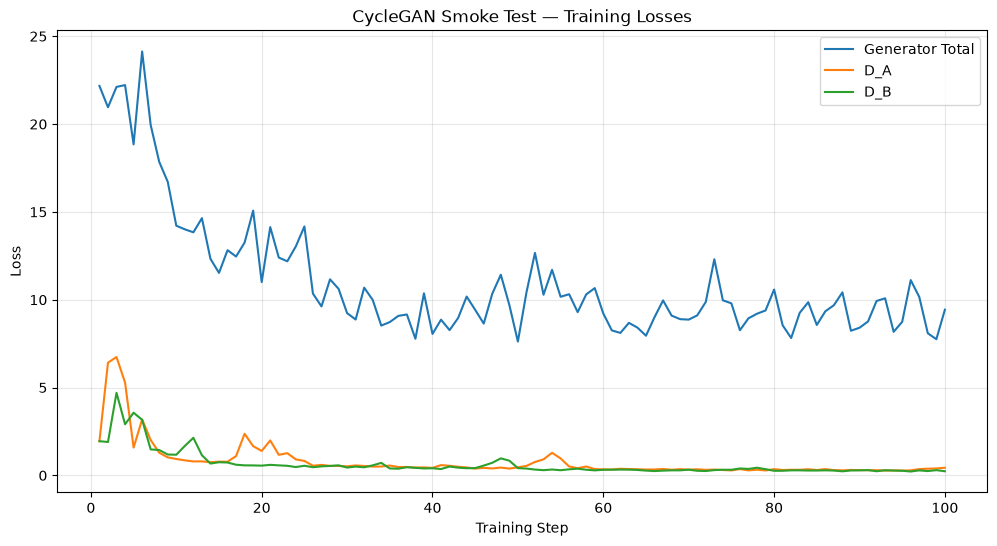

In [50]:
plt.figure(figsize=(12, 6))

plt.plot(
    smoke_df["step"],
    smoke_df["G_total"],
    label="Generator Total"
)

plt.plot(
    smoke_df["step"],
    smoke_df["D_A"],
    label="D_A"
)

plt.plot(
    smoke_df["step"],
    smoke_df["D_B"],
    label="D_B"
)

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("CycleGAN Smoke Test — Training Losses")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

cycle losses separately because they're on a different scale:

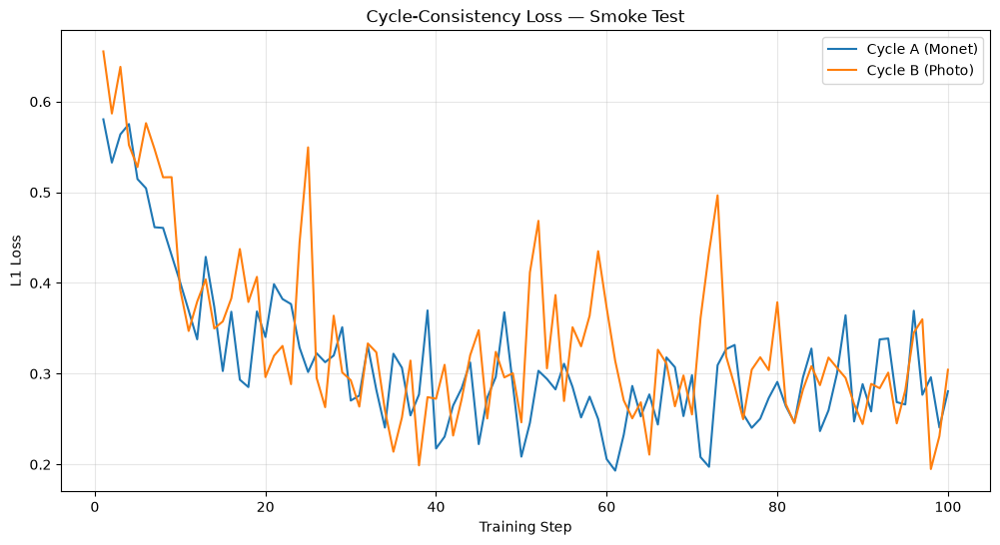

In [51]:
plt.figure(figsize=(12, 6))

plt.plot(
    smoke_df["step"],
    smoke_df["cycle_A"],
    label="Cycle A (Monet)"
)

plt.plot(
    smoke_df["step"],
    smoke_df["cycle_B"],
    label="Cycle B (Photo)"
)

plt.xlabel("Training Step")
plt.ylabel("L1 Loss")
plt.title("Cycle-Consistency Loss — Smoke Test")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Gradient stability

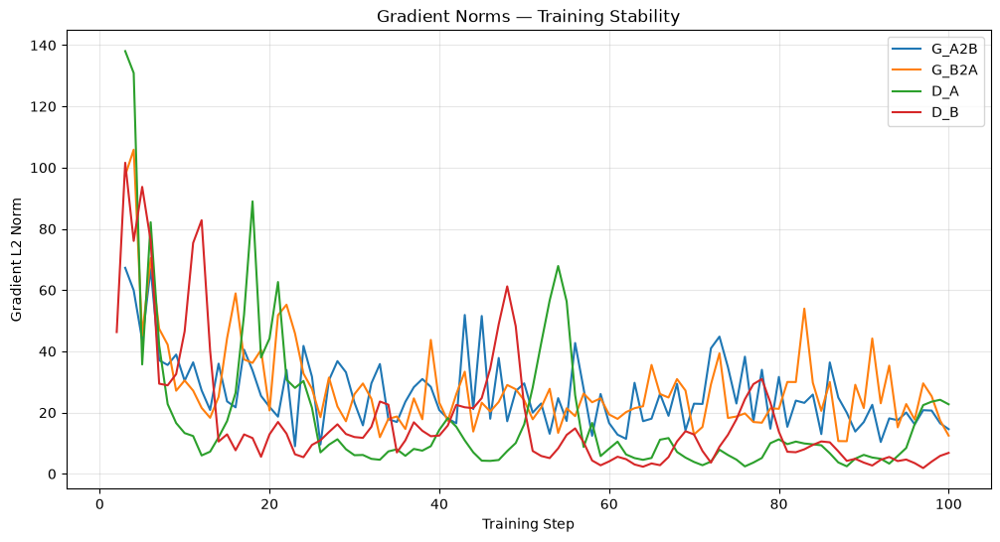

In [52]:
plt.figure(figsize=(12, 6))

plt.plot(
    smoke_df["step"],
    smoke_df["grad_G_A2B"],
    label="G_A2B"
)

plt.plot(
    smoke_df["step"],
    smoke_df["grad_G_B2A"],
    label="G_B2A"
)

plt.plot(
    smoke_df["step"],
    smoke_df["grad_D_A"],
    label="D_A"
)

plt.plot(
    smoke_df["step"],
    smoke_df["grad_D_B"],
    label="D_B"
)

plt.xlabel("Training Step")
plt.ylabel("Gradient L2 Norm")

plt.title(
    "Gradient Norms — Training Stability"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

See what 100 steps actually produced

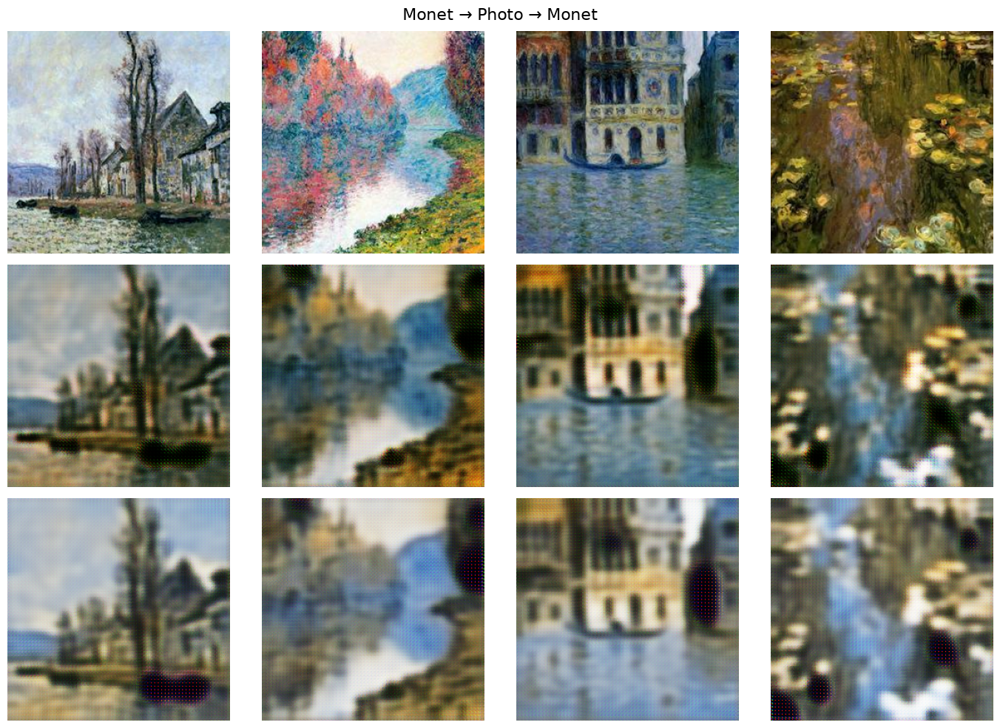

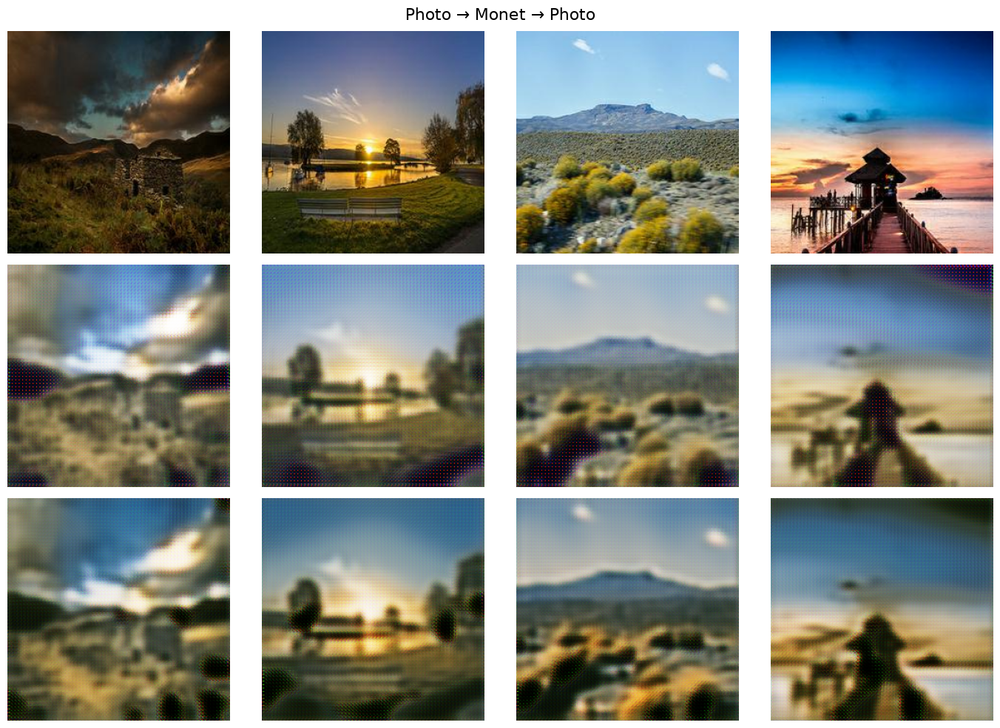

In [53]:
G_A2B.eval()
G_B2A.eval()

with torch.no_grad():

    sample_A = real_A[:4].to(device)
    sample_B = real_B[:4].to(device)

    generated_B = G_A2B(sample_A)
    reconstructed_A = G_B2A(generated_B)

    generated_A = G_B2A(sample_B)
    reconstructed_B = G_A2B(generated_A)


def show_translation(
    original,
    translated,
    reconstructed,
    title
):

    original = denormalize(
        original.detach().cpu()
    ).clamp(0, 1)

    translated = denormalize(
        translated.detach().cpu()
    ).clamp(0, 1)

    reconstructed = denormalize(
        reconstructed.detach().cpu()
    ).clamp(0, 1)

    n = min(
        4,
        original.shape[0]
    )

    fig, axes = plt.subplots(
        3,
        n,
        figsize=(14, 10)
    )

    for i in range(n):

        axes[0, i].imshow(
            original[i].permute(1, 2, 0)
        )

        axes[1, i].imshow(
            translated[i].permute(1, 2, 0)
        )

        axes[2, i].imshow(
            reconstructed[i].permute(1, 2, 0)
        )

        for row in range(3):
            axes[row, i].axis("off")

    axes[0, 0].set_ylabel(
        "Original",
        fontsize=12
    )

    axes[1, 0].set_ylabel(
        "Translation",
        fontsize=12
    )

    axes[2, 0].set_ylabel(
        "Reconstruction",
        fontsize=12
    )

    plt.suptitle(
        title,
        fontsize=16
    )

    plt.tight_layout()
    plt.show()


show_translation(
    sample_A,
    generated_B,
    reconstructed_A,
    "Monet → Photo → Monet"
)


show_translation(
    sample_B,
    generated_A,
    reconstructed_B,
    "Photo → Monet → Photo"
)

Find exactly what caused the 2 incidents

In [54]:
problem_steps = smoke_df[
    (~smoke_df["losses_finite"]) |
    (~smoke_df["gradients_finite"])
]

display(problem_steps)

,step,G_total,G_A2B_adv,G_B2A_adv,cycle_A,cycle_B,identity_A,identity_B,D_A,D_B,grad_G_A2B,grad_G_B2A,grad_D_A,grad_D_B,memory_MB,peak_memory_MB,losses_finite,gradients_finite
0,1,22.171356,1.338199,2.363167,0.580379,0.655241,0.567929,0.654830,1.945083,1.948040,inf,inf,28.12117,inf,275.896973,11363.806641,True,False
1,2,20.956947,1.221276,3.008564,0.532698,0.586793,0.515769,0.590672,6.416506,1.901114,inf,inf,inf,46.29246,305.272949,11363.806641,True,False


In [55]:
print("Loss failures:")
display(
    smoke_df[
        smoke_df["losses_finite"] == False
    ]
)

print("\nGradient failures:")
display(
    smoke_df[
        smoke_df["gradients_finite"] == False
    ]
)

Loss failures:


,step,G_total,G_A2B_adv,G_B2A_adv,cycle_A,cycle_B,identity_A,identity_B,D_A,D_B,grad_G_A2B,grad_G_B2A,grad_D_A,grad_D_B,memory_MB,peak_memory_MB,losses_finite,gradients_finite



Gradient failures:


,step,G_total,G_A2B_adv,G_B2A_adv,cycle_A,cycle_B,identity_A,identity_B,D_A,D_B,grad_G_A2B,grad_G_B2A,grad_D_A,grad_D_B,memory_MB,peak_memory_MB,losses_finite,gradients_finite
0,1,22.171356,1.338199,2.363167,0.580379,0.655241,0.567929,0.654830,1.945083,1.948040,inf,inf,28.12117,inf,275.896973,11363.806641,True,False
1,2,20.956947,1.221276,3.008564,0.532698,0.586793,0.515769,0.590672,6.416506,1.901114,inf,inf,inf,46.29246,305.272949,11363.806641,True,False


Delete smoke-test models

In [56]:
# ============================================================
# CELL 47 — RESET SMOKE-TEST MODELS
# ============================================================

# The previous networks were modified by the 100-step smoke test.
# Delete them so the final experiment starts from fresh weights.

del G_A2B
del G_B2A
del D_A
del D_B

del optimizer_G
del optimizer_D_A
del optimizer_D_B

# Delete schedulers if they currently exist
if "scheduler_G" in globals():
    del scheduler_G

if "scheduler_D_A" in globals():
    del scheduler_D_A

if "scheduler_D_B" in globals():
    del scheduler_D_B

# Delete FP16 scaler from smoke test
if "scaler" in globals():
    del scaler

torch.cuda.empty_cache()

print("Smoke-test models and optimizers removed.")
print(
    "GPU allocated memory:",
    round(torch.cuda.memory_allocated() / 1024**2, 2),
    "MB"
)

Smoke-test models and optimizers removed.
GPU allocated memory: 299.81 MB


Reset random seeds

In [57]:
# ============================================================
# CELL 48 — RESET RANDOM SEEDS
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Random seed reset to:", SEED)

Random seed reset to: 42


Create completely fresh CycleGAN

In [58]:
# ============================================================
# CELL 49 — FRESH CYCLEGAN NETWORKS
# ============================================================

G_A2B = ResNetGenerator(
    input_channels=3,
    output_channels=3,
    num_residual_blocks=NUM_RESIDUAL_BLOCKS
).to(device)

G_B2A = ResNetGenerator(
    input_channels=3,
    output_channels=3,
    num_residual_blocks=NUM_RESIDUAL_BLOCKS
).to(device)

D_A = PatchGANDiscriminator(
    input_channels=3
).to(device)

D_B = PatchGANDiscriminator(
    input_channels=3
).to(device)


# Fresh CycleGAN weight initialization
G_A2B.apply(init_weights)
G_B2A.apply(init_weights)
D_A.apply(init_weights)
D_B.apply(init_weights)


print("Fresh CycleGAN initialized.")
print("G_A2B = Monet -> Photo")
print("G_B2A = Photo -> Monet")
print("D_A   = Monet discriminator")
print("D_B   = Photo discriminator")

Fresh CycleGAN initialized.
G_A2B = Monet -> Photo
G_B2A = Photo -> Monet
D_A   = Monet discriminator
D_B   = Photo discriminator


Verify parameter counts haven't changed

In [59]:
# ============================================================
# CELL 50 — PARAMETER VERIFICATION
# ============================================================

for name, model in {
    "G_A2B": G_A2B,
    "G_B2A": G_B2A,
    "D_A": D_A,
    "D_B": D_B
}.items():

    total, trainable = count_parameters(model)

    print(
        f"{name:6s} | "
        f"Total: {total:,} | "
        f"Trainable: {trainable:,}"
    )


total_parameters = sum(
    count_parameters(model)[0]
    for model in [G_A2B, G_B2A, D_A, D_B]
)

print("\nTotal CycleGAN parameters:",
      f"{total_parameters:,}")

G_A2B  | Total: 11,372,931 | Trainable: 11,372,931
G_B2A  | Total: 11,372,931 | Trainable: 11,372,931
D_A    | Total: 2,764,737 | Trainable: 2,764,737
D_B    | Total: 2,764,737 | Trainable: 2,764,737

Total CycleGAN parameters: 28,275,336


Create fresh optimizers

In [60]:
# ============================================================
# CELL 51 — OPTIMIZERS
# ============================================================

optimizer_G = optim.Adam(
    list(G_A2B.parameters()) +
    list(G_B2A.parameters()),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2)
)

optimizer_D_A = optim.Adam(
    D_A.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2)
)

optimizer_D_B = optim.Adam(
    D_B.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2)
)

print("Fresh optimizers created.")
print("Learning rate:", LEARNING_RATE)
print("Betas:", (BETA1, BETA2))

Fresh optimizers created.
Learning rate: 0.0002
Betas: (0.5, 0.999)


Fresh replay buffers

In [61]:
# ============================================================
# CELL 52 — IMAGE REPLAY BUFFERS
# ============================================================

POOL_SIZE = 50

fake_A_pool = ImagePool(
    pool_size=POOL_SIZE
)

fake_B_pool = ImagePool(
    pool_size=POOL_SIZE
)

print("Replay buffers initialized.")
print("Pool size:", POOL_SIZE)

Replay buffers initialized.
Pool size: 50


Switch from FP16 to BF16

In [62]:
# ============================================================
# CELL 53 — MIXED PRECISION CONFIGURATION
# ============================================================

BF16_SUPPORTED = torch.cuda.is_bf16_supported()

print("BF16 supported:", BF16_SUPPORTED)

assert BF16_SUPPORTED, (
    "BF16 is not supported on this GPU."
)

USE_AMP = True
AMP_DTYPE = torch.bfloat16

print("AMP enabled:", USE_AMP)
print("AMP dtype:", AMP_DTYPE)

BF16 supported: True
AMP enabled: True
AMP dtype: torch.bfloat16


Final training configuration

In [63]:
# ============================================================
# CELL 54 — FINAL TRAINING CONFIGURATION
# ============================================================

TOTAL_EPOCHS = 200

DECAY_START_EPOCH = 100

CHECKPOINT_INTERVAL = 10

SAMPLE_INTERVAL = 5

BATCH_SIZE = 4

print("=" * 60)
print("FINAL TRAINING CONFIGURATION")
print("=" * 60)

print("Epochs:", TOTAL_EPOCHS)
print("LR decay begins:", DECAY_START_EPOCH)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)

print("Lambda cycle:", LAMBDA_CYCLE)
print("Lambda identity:", LAMBDA_IDENTITY)

print("Replay buffer:", POOL_SIZE)

print("AMP:", USE_AMP)
print("AMP dtype:", AMP_DTYPE)

print("Checkpoint interval:",
      CHECKPOINT_INTERVAL)

print("Sample interval:",
      SAMPLE_INTERVAL)

FINAL TRAINING CONFIGURATION
Epochs: 200
LR decay begins: 100
Batch size: 4
Learning rate: 0.0002
Lambda cycle: 10
Lambda identity: 5
Replay buffer: 50
AMP: True
AMP dtype: torch.bfloat16
Checkpoint interval: 10
Sample interval: 5


Balanced unpaired dataset

In [64]:
# ============================================================
# CELL 55 — BALANCED UNPAIRED DATASET
# ============================================================

class BalancedUnpairedDataset(Dataset):

    def __init__(
        self,
        domain_a_paths,
        domain_b_paths,
        transform=None
    ):

        self.domain_a_paths = list(
            domain_a_paths
        )

        self.domain_b_paths = list(
            domain_b_paths
        )

        self.transform = transform

        # Monet is our smaller domain.
        # Each Monet appears once per epoch.
        self.length = len(
            self.domain_a_paths
        )


    def __len__(self):

        return self.length


    def __getitem__(self, index):

        # ----------------------------------------------------
        # DOMAIN A — MONET
        #
        # Deterministic indexing means every Monet training
        # image is used once per epoch.
        # DataLoader shuffle randomizes their order.
        # ----------------------------------------------------

        a_path = self.domain_a_paths[
            index % len(self.domain_a_paths)
        ]

        # ----------------------------------------------------
        # DOMAIN B — PHOTO
        #
        # Independently/randomly sampled because training
        # is unpaired.
        # ----------------------------------------------------

        b_path = random.choice(
            self.domain_b_paths
        )

        with Image.open(a_path) as image_a:
            image_a = image_a.convert("RGB")

        with Image.open(b_path) as image_b:
            image_b = image_b.convert("RGB")

        if self.transform is not None:

            image_a = self.transform(
                image_a
            )

            image_b = self.transform(
                image_b
            )

        return {
            "A": image_a,
            "B": image_b,

            "A_path": str(a_path),
            "B_path": str(b_path)
        }


print("BalancedUnpairedDataset defined.")

BalancedUnpairedDataset defined.


Recreate training dataset + loader

In [65]:
# ============================================================
# CELL 56 — FINAL TRAINING DATALOADER
# ============================================================

train_dataset = BalancedUnpairedDataset(
    domain_a_paths=monet_train,
    domain_b_paths=photo_train,
    transform=train_transform
)

train_loader = DataLoader(
    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=True,

    drop_last=True
)


print("=" * 60)
print("FINAL TRAINING DATA")
print("=" * 60)

print(
    "Monet training images:",
    len(monet_train)
)

print(
    "Available photo training images:",
    len(photo_train)
)

print(
    "Samples per epoch:",
    len(train_dataset)
)

print(
    "Batches per epoch:",
    len(train_loader)
)

print(
    "Batch size:",
    BATCH_SIZE
)

FINAL TRAINING DATA
Monet training images: 270
Available photo training images: 6335
Samples per epoch: 270
Batches per epoch: 67
Batch size: 4


Test final loader

In [66]:
# ============================================================
# CELL 57 — FINAL DATALOADER SANITY CHECK
# ============================================================

test_batch = next(
    iter(train_loader)
)

test_A = test_batch["A"]
test_B = test_batch["B"]

print("Monet batch:", test_A.shape)
print("Photo batch:", test_B.shape)

print(
    "Monet range:",
    test_A.min().item(),
    test_A.max().item()
)

print(
    "Photo range:",
    test_B.min().item(),
    test_B.max().item()
)

Monet batch: torch.Size([4, 3, 256, 256])
Photo batch: torch.Size([4, 3, 256, 256])
Monet range: -1.0 1.0
Photo range: -1.0 1.0


Create learning-rate schedulers

In [67]:
# ============================================================
# CELL 58 — LEARNING RATE SCHEDULERS
# ============================================================

def lr_lambda(epoch):

    if epoch < DECAY_START_EPOCH:
        return 1.0

    decay_progress = (
        epoch - DECAY_START_EPOCH
    ) / (
        TOTAL_EPOCHS
        - DECAY_START_EPOCH
    )

    return max(
        0.0,
        1.0 - decay_progress
    )


scheduler_G = optim.lr_scheduler.LambdaLR(
    optimizer_G,
    lr_lambda=lr_lambda
)

scheduler_D_A = optim.lr_scheduler.LambdaLR(
    optimizer_D_A,
    lr_lambda=lr_lambda
)

scheduler_D_B = optim.lr_scheduler.LambdaLR(
    optimizer_D_B,
    lr_lambda=lr_lambda
)


print("Learning-rate schedulers created.")

print(
    "Initial generator LR:",
    optimizer_G.param_groups[0]["lr"]
)

Learning-rate schedulers created.
Initial generator LR: 0.0002


Create fixed visualization samples

In [68]:
# ============================================================
# CELL 59 — FIXED VALIDATION SAMPLES
# ============================================================

def load_fixed_samples(
    paths,
    transform,
    count=4
):

    selected_paths = paths[:count]

    images = []

    for path in selected_paths:

        with Image.open(path) as image:

            image = image.convert("RGB")

            image = transform(image)

            images.append(image)

    return torch.stack(images)


fixed_A = load_fixed_samples(
    monet_val,
    eval_transform,
    count=4
).to(device)


fixed_B = load_fixed_samples(
    photo_val,
    eval_transform,
    count=4
).to(device)


print("Fixed Monet samples:",
      fixed_A.shape)

print("Fixed Photo samples:",
      fixed_B.shape)

Fixed Monet samples: torch.Size([4, 3, 256, 256])
Fixed Photo samples: torch.Size([4, 3, 256, 256])


Fresh training history

In [69]:
# ============================================================
# CELL 60 — TRAINING HISTORY
# ============================================================

training_history = []

epoch_history = []

nan_inf_count = 0

global_step = 0

print("Training history initialized.")

Training history initialized.


Final sample-saving function

In [70]:
# ============================================================
# CELL 61 — SAVE FIXED VALIDATION SAMPLES
# ============================================================

@torch.no_grad()
def save_fixed_samples(epoch):

    G_A2B.eval()
    G_B2A.eval()

    # --------------------------------------------------------
    # Monet -> Photo -> Monet
    # --------------------------------------------------------

    fake_B = G_A2B(fixed_A)
    reconstructed_A = G_B2A(fake_B)

    # --------------------------------------------------------
    # Photo -> Monet -> Photo
    # --------------------------------------------------------

    fake_A = G_B2A(fixed_B)
    reconstructed_B = G_A2B(fake_A)

    # Each row:
    # original images
    # translated images
    # reconstructed images

    grid_A = torch.cat(
        [
            fixed_A,
            fake_B,
            reconstructed_A
        ],
        dim=0
    )

    grid_B = torch.cat(
        [
            fixed_B,
            fake_A,
            reconstructed_B
        ],
        dim=0
    )

    save_image(
        denormalize(grid_A).clamp(0, 1),
        SAMPLE_DIR / f"epoch_{epoch:03d}_monet_cycle.jpg",
        nrow=4
    )

    save_image(
        denormalize(grid_B).clamp(0, 1),
        SAMPLE_DIR / f"epoch_{epoch:03d}_photo_cycle.jpg",
        nrow=4
    )

    G_A2B.train()
    G_B2A.train()

Robust checkpoint function

In [71]:
# ============================================================
# CELL 62 — CHECKPOINT SYSTEM
# ============================================================

def save_full_checkpoint(epoch):

    checkpoint = {

        "epoch": epoch,

        "global_step": global_step,

        # Models
        "G_A2B": G_A2B.state_dict(),
        "G_B2A": G_B2A.state_dict(),
        "D_A": D_A.state_dict(),
        "D_B": D_B.state_dict(),

        # Optimizers
        "optimizer_G":
            optimizer_G.state_dict(),

        "optimizer_D_A":
            optimizer_D_A.state_dict(),

        "optimizer_D_B":
            optimizer_D_B.state_dict(),

        # Schedulers
        "scheduler_G":
            scheduler_G.state_dict(),

        "scheduler_D_A":
            scheduler_D_A.state_dict(),

        "scheduler_D_B":
            scheduler_D_B.state_dict(),

        # History
        "training_history":
            training_history,

        "epoch_history":
            epoch_history,

        "nan_inf_count":
            nan_inf_count,

        # Configuration
        "seed":
            SEED,

        "batch_size":
            BATCH_SIZE,

        "learning_rate":
            LEARNING_RATE,

        "lambda_cycle":
            LAMBDA_CYCLE,

        "lambda_identity":
            LAMBDA_IDENTITY
    }

    # --------------------------------------------------------
    # Permanent epoch checkpoint
    # --------------------------------------------------------

    checkpoint_path = (
        CHECKPOINT_DIR /
        f"cyclegan_epoch_{epoch:03d}.pth"
    )

    torch.save(
        checkpoint,
        checkpoint_path
    )

    # --------------------------------------------------------
    # Latest checkpoint
    # --------------------------------------------------------

    latest_path = (
        CHECKPOINT_DIR /
        "latest_checkpoint.pth"
    )

    torch.save(
        checkpoint,
        latest_path
    )

    print(
        f"Checkpoint saved: epoch {epoch}"
    )

Save history continuously

In [72]:
# ============================================================
# CELL 63 — HISTORY SAVING
# ============================================================

def save_training_history():

    if len(training_history) > 0:

        step_df = pd.DataFrame(
            training_history
        )

        step_df.to_csv(
            OUTPUT_DIR /
            "training_history_steps.csv",
            index=False
        )

    if len(epoch_history) > 0:

        epoch_df = pd.DataFrame(
            epoch_history
        )

        epoch_df.to_csv(
            OUTPUT_DIR /
            "training_history_epochs.csv",
            index=False
        )

Final training loop

In [73]:
# ============================================================
# CELL 64 — FINAL CYCLEGAN TRAINING
# ============================================================

G_A2B.train()
G_B2A.train()
D_A.train()
D_B.train()

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

training_start_time = time.perf_counter()

print("=" * 75)
print("STARTING FINAL CYCLEGAN TRAINING")
print("=" * 75)

print("Epochs:", TOTAL_EPOCHS)
print("Batches/epoch:", len(train_loader))
print("Batch size:", BATCH_SIZE)
print("AMP dtype:", AMP_DTYPE)
print("Device:", device)

print("=" * 75)


for epoch in range(1, TOTAL_EPOCHS + 1):

    epoch_start_time = time.perf_counter()

    # --------------------------------------------------------
    # Epoch accumulators
    # --------------------------------------------------------

    epoch_G = 0.0
    epoch_D_A = 0.0
    epoch_D_B = 0.0

    epoch_cycle_A = 0.0
    epoch_cycle_B = 0.0

    epoch_identity_A = 0.0
    epoch_identity_B = 0.0

    epoch_adv_A2B = 0.0
    epoch_adv_B2A = 0.0

    epoch_invalid = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch:03d}/{TOTAL_EPOCHS}",
        leave=False
    )

    # ========================================================
    # BATCH LOOP
    # ========================================================

    for batch_index, batch in enumerate(progress_bar):

        global_step += 1

        # ====================================================
        # DATA
        # ====================================================

        real_A = batch["A"].to(
            device,
            non_blocking=True
        )

        real_B = batch["B"].to(
            device,
            non_blocking=True
        )

        # ====================================================
        # TRAIN GENERATORS
        # ====================================================

        optimizer_G.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=USE_AMP
        ):

            # -----------------------------------------------
            # Translation
            # -----------------------------------------------

            fake_B = G_A2B(real_A)
            fake_A = G_B2A(real_B)

            # -----------------------------------------------
            # Adversarial losses
            # -----------------------------------------------

            pred_fake_B = D_B(fake_B)

            loss_G_A2B_adv = criterion_GAN(
                pred_fake_B,
                torch.ones_like(pred_fake_B)
            )


            pred_fake_A = D_A(fake_A)

            loss_G_B2A_adv = criterion_GAN(
                pred_fake_A,
                torch.ones_like(pred_fake_A)
            )

            # -----------------------------------------------
            # Cycle consistency
            # -----------------------------------------------

            reconstructed_A = G_B2A(
                fake_B
            )

            reconstructed_B = G_A2B(
                fake_A
            )


            loss_cycle_A = criterion_cycle(
                reconstructed_A,
                real_A
            )

            loss_cycle_B = criterion_cycle(
                reconstructed_B,
                real_B
            )

            # -----------------------------------------------
            # Identity
            # -----------------------------------------------

            identity_A = G_B2A(
                real_A
            )

            identity_B = G_A2B(
                real_B
            )

            loss_identity_A = (
                criterion_identity(
                    identity_A,
                    real_A
                )
            )

            loss_identity_B = (
                criterion_identity(
                    identity_B,
                    real_B
                )
            )

            # -----------------------------------------------
            # Total generator loss
            # -----------------------------------------------

            loss_G = (
                loss_G_A2B_adv
                +
                loss_G_B2A_adv
                +
                LAMBDA_CYCLE
                *
                (
                    loss_cycle_A
                    +
                    loss_cycle_B
                )
                +
                LAMBDA_IDENTITY
                *
                (
                    loss_identity_A
                    +
                    loss_identity_B
                )
            )

        loss_G.backward()

        grad_G_A2B = get_gradient_norm(
            G_A2B
        )

        grad_G_B2A = get_gradient_norm(
            G_B2A
        )

        G_gradients_finite = (
            gradients_are_finite(G_A2B)
            and
            gradients_are_finite(G_B2A)
        )

        optimizer_G.step()

        # ====================================================
        # TRAIN DISCRIMINATOR A
        # ====================================================

        optimizer_D_A.zero_grad(
            set_to_none=True
        )

        fake_A_buffered = fake_A_pool.query(
            fake_A.detach()
        )

        with torch.amp.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=USE_AMP
        ):

            prediction_real_A = D_A(
                real_A
            )

            loss_D_A_real = criterion_GAN(
                prediction_real_A,
                torch.ones_like(
                    prediction_real_A
                )
            )

            prediction_fake_A = D_A(
                fake_A_buffered
            )

            loss_D_A_fake = criterion_GAN(
                prediction_fake_A,
                torch.zeros_like(
                    prediction_fake_A
                )
            )

            loss_D_A = (
                loss_D_A_real
                +
                loss_D_A_fake
            ) * 0.5

        loss_D_A.backward()

        grad_D_A = get_gradient_norm(
            D_A
        )

        D_A_gradients_finite = (
            gradients_are_finite(D_A)
        )

        optimizer_D_A.step()

        # ====================================================
        # TRAIN DISCRIMINATOR B
        # ====================================================

        optimizer_D_B.zero_grad(
            set_to_none=True
        )

        fake_B_buffered = fake_B_pool.query(
            fake_B.detach()
        )

        with torch.amp.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=USE_AMP
        ):

            prediction_real_B = D_B(
                real_B
            )

            loss_D_B_real = criterion_GAN(
                prediction_real_B,
                torch.ones_like(
                    prediction_real_B
                )
            )

            prediction_fake_B = D_B(
                fake_B_buffered
            )

            loss_D_B_fake = criterion_GAN(
                prediction_fake_B,
                torch.zeros_like(
                    prediction_fake_B
                )
            )

            loss_D_B = (
                loss_D_B_real
                +
                loss_D_B_fake
            ) * 0.5

        loss_D_B.backward()

        grad_D_B = get_gradient_norm(
            D_B
        )

        D_B_gradients_finite = (
            gradients_are_finite(D_B)
        )

        optimizer_D_B.step()

        # ====================================================
        # STABILITY CHECK
        # ====================================================

        current_losses = [

            loss_G,

            loss_G_A2B_adv,
            loss_G_B2A_adv,

            loss_cycle_A,
            loss_cycle_B,

            loss_identity_A,
            loss_identity_B,

            loss_D_A,
            loss_D_B
        ]

        losses_finite = all(
            torch.isfinite(loss).item()
            for loss in current_losses
        )

        gradients_finite = (
            G_gradients_finite
            and
            D_A_gradients_finite
            and
            D_B_gradients_finite
        )

        invalid_this_step = (
            not losses_finite
            or
            not gradients_finite
        )

        if invalid_this_step:

            nan_inf_count += 1
            epoch_invalid += 1

        # ====================================================
        # GPU MEMORY
        # ====================================================

        gpu_memory_mb = (
            torch.cuda.memory_allocated()
            / 1024**2
        )

        peak_gpu_memory_mb = (
            torch.cuda.max_memory_allocated()
            / 1024**2
        )

        # ====================================================
        # RECORD STEP
        # ====================================================

        current_lr = (
            optimizer_G.param_groups[0]["lr"]
        )

        training_history.append({

            "epoch":
                epoch,

            "step":
                global_step,

            "batch":
                batch_index + 1,

            "G_total":
                loss_G.item(),

            "G_A2B_adv":
                loss_G_A2B_adv.item(),

            "G_B2A_adv":
                loss_G_B2A_adv.item(),

            "cycle_A":
                loss_cycle_A.item(),

            "cycle_B":
                loss_cycle_B.item(),

            "identity_A":
                loss_identity_A.item(),

            "identity_B":
                loss_identity_B.item(),

            "D_A":
                loss_D_A.item(),

            "D_B":
                loss_D_B.item(),

            "grad_G_A2B":
                grad_G_A2B,

            "grad_G_B2A":
                grad_G_B2A,

            "grad_D_A":
                grad_D_A,

            "grad_D_B":
                grad_D_B,

            "learning_rate":
                current_lr,

            "gpu_memory_MB":
                gpu_memory_mb,

            "peak_gpu_memory_MB":
                peak_gpu_memory_mb,

            "losses_finite":
                losses_finite,

            "gradients_finite":
                gradients_finite
        })

        # ====================================================
        # EPOCH ACCUMULATION
        # ====================================================

        epoch_G += loss_G.item()

        epoch_D_A += loss_D_A.item()
        epoch_D_B += loss_D_B.item()

        epoch_cycle_A += (
            loss_cycle_A.item()
        )

        epoch_cycle_B += (
            loss_cycle_B.item()
        )

        epoch_identity_A += (
            loss_identity_A.item()
        )

        epoch_identity_B += (
            loss_identity_B.item()
        )

        epoch_adv_A2B += (
            loss_G_A2B_adv.item()
        )

        epoch_adv_B2A += (
            loss_G_B2A_adv.item()
        )

        # ====================================================
        # PROGRESS DISPLAY
        # ====================================================

        progress_bar.set_postfix({

            "G":
                f"{loss_G.item():.2f}",

            "DA":
                f"{loss_D_A.item():.2f}",

            "DB":
                f"{loss_D_B.item():.2f}",

            "cycA":
                f"{loss_cycle_A.item():.3f}",

            "cycB":
                f"{loss_cycle_B.item():.3f}"
        })

    # ========================================================
    # END OF EPOCH
    # ========================================================

    num_batches = len(
        train_loader
    )

    epoch_time = (
        time.perf_counter()
        -
        epoch_start_time
    )

    # --------------------------------------------------------
    # Epoch averages
    # --------------------------------------------------------

    avg_G = (
        epoch_G / num_batches
    )

    avg_D_A = (
        epoch_D_A / num_batches
    )

    avg_D_B = (
        epoch_D_B / num_batches
    )

    avg_cycle_A = (
        epoch_cycle_A / num_batches
    )

    avg_cycle_B = (
        epoch_cycle_B / num_batches
    )

    avg_identity_A = (
        epoch_identity_A / num_batches
    )

    avg_identity_B = (
        epoch_identity_B / num_batches
    )

    avg_adv_A2B = (
        epoch_adv_A2B / num_batches
    )

    avg_adv_B2A = (
        epoch_adv_B2A / num_batches
    )

    # --------------------------------------------------------
    # Throughput
    # --------------------------------------------------------

    input_images_this_epoch = (
        num_batches
        *
        BATCH_SIZE
        *
        2
    )

    epoch_images_per_second = (
        input_images_this_epoch
        /
        epoch_time
    )

    # --------------------------------------------------------
    # Epoch history
    # --------------------------------------------------------

    epoch_history.append({

        "epoch":
            epoch,

        "G_total":
            avg_G,

        "G_A2B_adv":
            avg_adv_A2B,

        "G_B2A_adv":
            avg_adv_B2A,

        "cycle_A":
            avg_cycle_A,

        "cycle_B":
            avg_cycle_B,

        "identity_A":
            avg_identity_A,

        "identity_B":
            avg_identity_B,

        "D_A":
            avg_D_A,

        "D_B":
            avg_D_B,

        "learning_rate":
            optimizer_G.param_groups[0]["lr"],

        "epoch_time_sec":
            epoch_time,

        "images_per_sec":
            epoch_images_per_second,

        "invalid_steps":
            epoch_invalid,

        "peak_gpu_memory_MB":
            torch.cuda.max_memory_allocated()
            / 1024**2
    })

    # --------------------------------------------------------
    # Scheduler update
    # --------------------------------------------------------

    scheduler_G.step()
    scheduler_D_A.step()
    scheduler_D_B.step()

    # --------------------------------------------------------
    # Save history after EVERY epoch
    # --------------------------------------------------------

    save_training_history()

    # --------------------------------------------------------
    # Save visual samples
    # --------------------------------------------------------

    if (
        epoch == 1
        or
        epoch % SAMPLE_INTERVAL == 0
    ):

        save_fixed_samples(
            epoch
        )

    # --------------------------------------------------------
    # Checkpoint
    # --------------------------------------------------------

    if (
        epoch % CHECKPOINT_INTERVAL == 0
        or
        epoch == TOTAL_EPOCHS
    ):

        save_full_checkpoint(
            epoch
        )

    # --------------------------------------------------------
    # Console summary
    # --------------------------------------------------------

    print(
        f"Epoch {epoch:03d}/{TOTAL_EPOCHS} | "
        f"G={avg_G:.4f} | "
        f"D_A={avg_D_A:.4f} | "
        f"D_B={avg_D_B:.4f} | "
        f"CycleA={avg_cycle_A:.4f} | "
        f"CycleB={avg_cycle_B:.4f} | "
        f"LR={optimizer_G.param_groups[0]['lr']:.7f} | "
        f"{epoch_time:.1f}s | "
        f"{epoch_images_per_second:.1f} img/s | "
        f"Invalid={epoch_invalid}"
    )


# ============================================================
# TRAINING COMPLETE
# ============================================================

torch.cuda.synchronize()

total_training_time = (
    time.perf_counter()
    -
    training_start_time
)

peak_memory_gb = (
    torch.cuda.max_memory_allocated()
    /
    1024**3
)

print("\n" + "=" * 75)
print("TRAINING COMPLETE")
print("=" * 75)

print(
    "Total epochs:",
    TOTAL_EPOCHS
)

print(
    "Total steps:",
    global_step
)

print(
    "Training time:",
    f"{total_training_time / 60:.2f} minutes"
)

print(
    "Peak GPU memory:",
    f"{peak_memory_gb:.2f} GB"
)

print(
    "NaN/Inf incidents:",
    nan_inf_count
)

print("=" * 75)

STARTING FINAL CYCLEGAN TRAINING
Epochs: 200
Batches/epoch: 67
Batch size: 4
AMP dtype: torch.bfloat16
Device: cuda


Epoch 001/200:   0%|          | 0/67 [00:00<?, ?it/s]

Epoch 001/200 | G=11.5394 | D_A=0.8651 | D_B=0.8109 | CycleA=0.3261 | CycleB=0.3483 | LR=0.0002000 | 14.6s | 36.7 img/s | Invalid=0


Epoch 002/200:   0%|          | 0/67 [00:00<?, ?it/s]

Epoch 002/200 | G=9.2876 | D_A=0.3171 | D_B=0.3118 | CycleA=0.2739 | CycleB=0.3070 | LR=0.0002000 | 10.9s | 49.4 img/s | Invalid=0


...

Epoch 198/200 | G=3.7392 | D_A=0.1179 | D_B=0.1503 | CycleA=0.0772 | CycleB=0.1033 | LR=0.0000040 | 10.6s | 50.8 img/s | Invalid=0


Epoch 199/200:   0%|          | 0/67 [00:00<?, ?it/s]

Epoch 199/200 | G=3.6774 | D_A=0.1221 | D_B=0.1567 | CycleA=0.0768 | CycleB=0.0993 | LR=0.0000020 | 10.6s | 50.4 img/s | Invalid=0


Epoch 200/200:   0%|          | 0/67 [00:00<?, ?it/s]

Checkpoint saved: epoch 200
Epoch 200/200 | G=3.6724 | D_A=0.1179 | D_B=0.1522 | CycleA=0.0769 | CycleB=0.0984 | LR=0.0000000 | 10.6s | 50.6 img/s | Invalid=0

TRAINING COMPLETE
Total epochs: 200
Total steps: 13400
Training time: 36.01 minutes
Peak GPU memory: 4.89 GB
NaN/Inf incidents: 0


Immediately save final standalone models

In [74]:
# ============================================================
# CELL 65 — SAVE FINAL MODELS
# ============================================================

torch.save(
    G_A2B.state_dict(),
    CHECKPOINT_DIR / "G_A2B_final.pth"
)

torch.save(
    G_B2A.state_dict(),
    CHECKPOINT_DIR / "G_B2A_final.pth"
)

torch.save(
    D_A.state_dict(),
    CHECKPOINT_DIR / "D_A_final.pth"
)

torch.save(
    D_B.state_dict(),
    CHECKPOINT_DIR / "D_B_final.pth"
)

print("Final models saved.")

Final models saved.


Confirm final training state

In [75]:
# ============================================================
# CELL 66 — FINAL TRAINING SUMMARY
# ============================================================

print("=" * 70)
print("FINAL TRAINING SUMMARY")
print("=" * 70)

print("Epochs completed:", len(epoch_history))
print("Total optimization steps:", global_step)
print("NaN/Inf incidents:", nan_inf_count)

if len(epoch_history) > 0:
    final_epoch = epoch_history[-1]

    print("\nFinal epoch metrics:")
    print(f"G total      : {final_epoch['G_total']:.6f}")
    print(f"D_A          : {final_epoch['D_A']:.6f}")
    print(f"D_B          : {final_epoch['D_B']:.6f}")
    print(f"Cycle A      : {final_epoch['cycle_A']:.6f}")
    print(f"Cycle B      : {final_epoch['cycle_B']:.6f}")
    print(f"Identity A   : {final_epoch['identity_A']:.6f}")
    print(f"Identity B   : {final_epoch['identity_B']:.6f}")
    print(f"Final LR     : {final_epoch['learning_rate']:.8f}")
    print(f"Peak VRAM MB : {final_epoch['peak_gpu_memory_MB']:.2f}")

FINAL TRAINING SUMMARY
Epochs completed: 200
Total optimization steps: 13400
NaN/Inf incidents: 0

Final epoch metrics:
G total      : 3.672418
D_A          : 0.117884
D_B          : 0.152200
Cycle A      : 0.076917
Cycle B      : 0.098434
Identity A   : 0.080866
Identity B   : 0.096013
Final LR     : 0.00000200
Peak VRAM MB : 5003.37


Cell 67 — Put trained models in inference mode

In [76]:
# ============================================================
# CELL 67 — INFERENCE MODE
# ============================================================

G_A2B.eval()
G_B2A.eval()

D_A.eval()
D_B.eval()

for model in [G_A2B, G_B2A, D_A, D_B]:
    for parameter in model.parameters():
        parameter.requires_grad_(False)

print("Models frozen and placed in evaluation mode.")

Models frozen and placed in evaluation mode.


Plot generator/discriminator losses

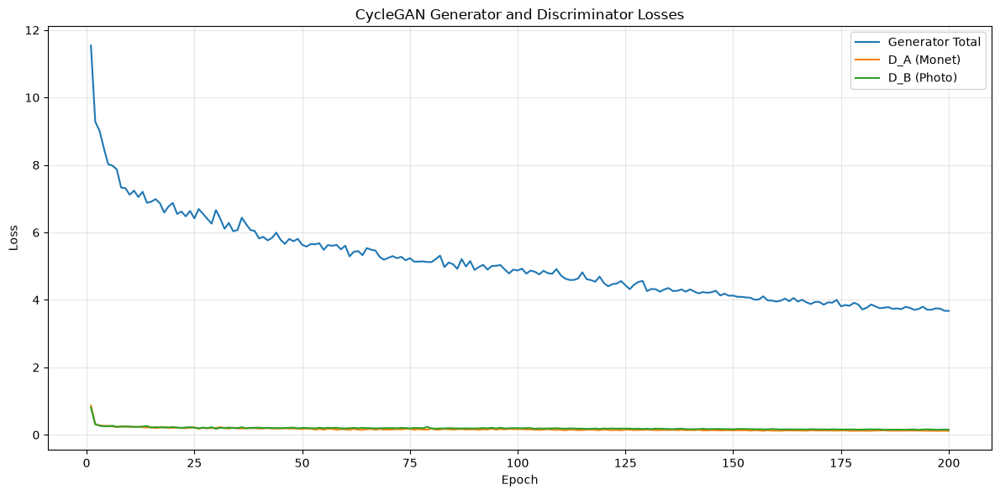

In [77]:
# ============================================================
# CELL 68 — GENERATOR / DISCRIMINATOR LOSS CURVES
# ============================================================

epoch_df = pd.DataFrame(epoch_history)

plt.figure(figsize=(12, 6))

plt.plot(
    epoch_df["epoch"],
    epoch_df["G_total"],
    label="Generator Total"
)

plt.plot(
    epoch_df["epoch"],
    epoch_df["D_A"],
    label="D_A (Monet)"
)

plt.plot(
    epoch_df["epoch"],
    epoch_df["D_B"],
    label="D_B (Photo)"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CycleGAN Generator and Discriminator Losses")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "generator_discriminator_losses.png",
    dpi=200
)

plt.show()

Cycle-consistency curves

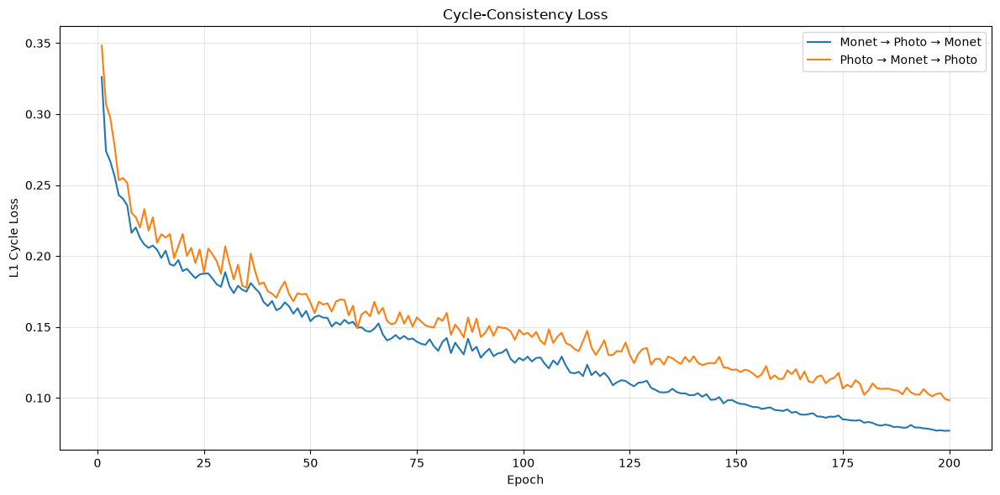

In [78]:
# ============================================================
# CELL 69 — CYCLE-CONSISTENCY LOSS
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    epoch_df["epoch"],
    epoch_df["cycle_A"],
    label="Monet → Photo → Monet"
)

plt.plot(
    epoch_df["epoch"],
    epoch_df["cycle_B"],
    label="Photo → Monet → Photo"
)

plt.xlabel("Epoch")
plt.ylabel("L1 Cycle Loss")
plt.title("Cycle-Consistency Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "cycle_consistency_loss.png",
    dpi=200
)

plt.show()

Identity loss curves

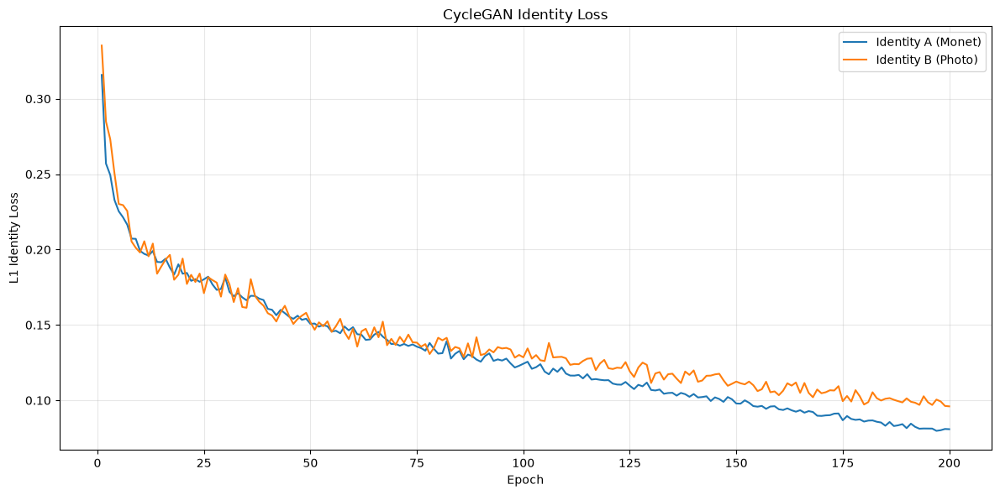

In [79]:
# ============================================================
# CELL 70 — IDENTITY LOSS
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    epoch_df["epoch"],
    epoch_df["identity_A"],
    label="Identity A (Monet)"
)

plt.plot(
    epoch_df["epoch"],
    epoch_df["identity_B"],
    label="Identity B (Photo)"
)

plt.xlabel("Epoch")
plt.ylabel("L1 Identity Loss")
plt.title("CycleGAN Identity Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "identity_loss.png",
    dpi=200
)

plt.show()

Learning-rate schedule

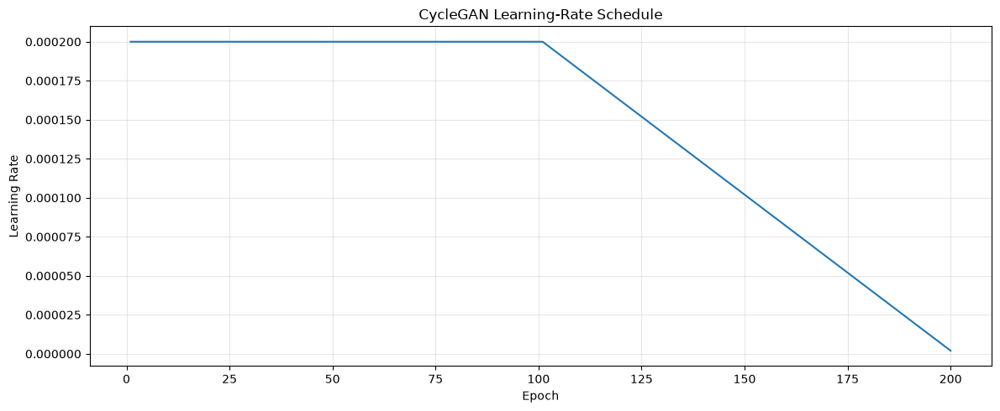

In [80]:
# ============================================================
# CELL 71 — LEARNING RATE
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    epoch_df["epoch"],
    epoch_df["learning_rate"]
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("CycleGAN Learning-Rate Schedule")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "learning_rate_schedule.png",
    dpi=200
)

plt.show()

Gradient norms

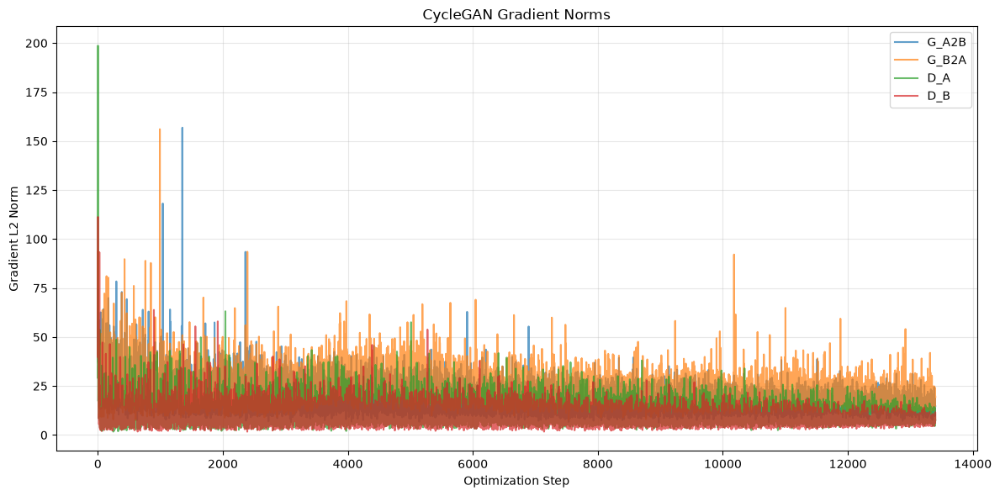

In [81]:
# ============================================================
# CELL 72 — GRADIENT NORMS
# ============================================================

step_df = pd.DataFrame(training_history)

plt.figure(figsize=(12, 6))

plt.plot(
    step_df["step"],
    step_df["grad_G_A2B"],
    label="G_A2B",
    alpha=0.7
)

plt.plot(
    step_df["step"],
    step_df["grad_G_B2A"],
    label="G_B2A",
    alpha=0.7
)

plt.plot(
    step_df["step"],
    step_df["grad_D_A"],
    label="D_A",
    alpha=0.7
)

plt.plot(
    step_df["step"],
    step_df["grad_D_B"],
    label="D_B",
    alpha=0.7
)

plt.xlabel("Optimization Step")
plt.ylabel("Gradient L2 Norm")
plt.title("CycleGAN Gradient Norms")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "gradient_norms.png",
    dpi=200
)

plt.show()

Stability statistics

In [82]:
# ============================================================
# CELL 73 — TRAINING STABILITY
# ============================================================

print("=" * 70)
print("TRAINING STABILITY")
print("=" * 70)

print("Total steps:", len(step_df))

print(
    "Non-finite loss steps:",
    (~step_df["losses_finite"]).sum()
)

print(
    "Non-finite gradient steps:",
    (~step_df["gradients_finite"]).sum()
)

print(
    "Recorded NaN/Inf incidents:",
    nan_inf_count
)

print("\nMaximum gradient norms:")

for column in [
    "grad_G_A2B",
    "grad_G_B2A",
    "grad_D_A",
    "grad_D_B"
]:
    print(
        f"{column:15s}: "
        f"{step_df[column].max():.4f}"
    )

TRAINING STABILITY
Total steps: 13400
Non-finite loss steps: 0
Non-finite gradient steps: 0
Recorded NaN/Inf incidents: 0

Maximum gradient norms:
grad_G_A2B     : 156.8587
grad_G_B2A     : 156.0666
grad_D_A       : 198.7008
grad_D_B       : 111.2919


Training performance

In [83]:
# ============================================================
# CELL 74 — TRAINING PERFORMANCE
# ============================================================

total_epoch_time = epoch_df[
    "epoch_time_sec"
].sum()

mean_throughput = epoch_df[
    "images_per_sec"
].mean()

peak_memory_mb = epoch_df[
    "peak_gpu_memory_MB"
].max()

print("=" * 70)
print("TRAINING PERFORMANCE")
print("=" * 70)

print(
    f"Training time: "
    f"{total_epoch_time / 60:.2f} minutes"
)

print(
    f"Mean input throughput: "
    f"{mean_throughput:.2f} images/sec"
)

print(
    f"Peak GPU memory: "
    f"{peak_memory_mb / 1024:.2f} GB"
)

print(
    f"Total parameters: "
    f"{total_parameters:,}"
)

TRAINING PERFORMANCE
Training time: 35.43 minutes
Mean input throughput: 50.46 images/sec
Peak GPU memory: 4.89 GB
Total parameters: 28,275,336


Create deterministic evaluation dataset

In [84]:
# ============================================================
# CELL 75 — EVALUATION DATASET
# ============================================================

class EvaluationDataset(Dataset):

    def __init__(self, paths, transform):

        self.paths = list(paths)
        self.transform = transform

    def __len__(self):

        return len(self.paths)

    def __getitem__(self, index):

        path = self.paths[index]

        with Image.open(path) as image:

            image = image.convert("RGB")
            image = self.transform(image)

        return image, path.name

Validation loaders

In [85]:
# ============================================================
# CELL 76 — VALIDATION LOADERS
# ============================================================

monet_val_dataset = EvaluationDataset(
    monet_val,
    eval_transform
)

photo_val_dataset = EvaluationDataset(
    photo_val,
    eval_transform
)


monet_val_loader = DataLoader(
    monet_val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

photo_val_loader = DataLoader(
    photo_val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


print("Monet validation images:", len(monet_val_dataset))
print("Photo validation images:", len(photo_val_dataset))

Monet validation images: 30
Photo validation images: 703


Create evaluation output directories

In [86]:
# ============================================================
# CELL 77 — EVALUATION DIRECTORIES
# ============================================================

EVAL_DIR = OUTPUT_DIR / "evaluation"

REAL_MONET_DIR = EVAL_DIR / "real_monet"
REAL_PHOTO_DIR = EVAL_DIR / "real_photo"

FAKE_MONET_DIR = EVAL_DIR / "fake_monet"
FAKE_PHOTO_DIR = EVAL_DIR / "fake_photo"

REC_MONET_DIR = EVAL_DIR / "reconstructed_monet"
REC_PHOTO_DIR = EVAL_DIR / "reconstructed_photo"

for directory in [
    REAL_MONET_DIR,
    REAL_PHOTO_DIR,
    FAKE_MONET_DIR,
    FAKE_PHOTO_DIR,
    REC_MONET_DIR,
    REC_PHOTO_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Evaluation directories ready.")

Evaluation directories ready.


Generate Monet → Photo → Monet

In [87]:
# ============================================================
# CELL 78 — MONET -> PHOTO -> MONET
# ============================================================

@torch.no_grad()
def generate_A2B_evaluation():

    G_A2B.eval()
    G_B2A.eval()

    for images, names in tqdm(
        monet_val_loader,
        desc="Monet -> Photo -> Monet"
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=USE_AMP
        ):

            fake_B = G_A2B(images)
            reconstructed_A = G_B2A(fake_B)

        for i, name in enumerate(names):

            save_image(
                denormalize(images[i]).clamp(0, 1),
                REAL_MONET_DIR / name
            )

            save_image(
                denormalize(fake_B[i]).clamp(0, 1),
                FAKE_PHOTO_DIR / name
            )

            save_image(
                denormalize(
                    reconstructed_A[i]
                ).clamp(0, 1),
                REC_MONET_DIR / name
            )


generate_A2B_evaluation()

print("Monet -> Photo evaluation complete.")

Monet -> Photo -> Monet:   0%|          | 0/4 [00:00<?, ?it/s]

Monet -> Photo evaluation complete.


Generate Photo → Monet → Photo

In [88]:
# ============================================================
# CELL 79 — PHOTO -> MONET -> PHOTO
# ============================================================

@torch.no_grad()
def generate_B2A_evaluation():

    G_A2B.eval()
    G_B2A.eval()

    for images, names in tqdm(
        photo_val_loader,
        desc="Photo -> Monet -> Photo"
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=USE_AMP
        ):

            fake_A = G_B2A(images)
            reconstructed_B = G_A2B(fake_A)

        for i, name in enumerate(names):

            save_image(
                denormalize(images[i]).clamp(0, 1),
                REAL_PHOTO_DIR / name
            )

            save_image(
                denormalize(fake_A[i]).clamp(0, 1),
                FAKE_MONET_DIR / name
            )

            save_image(
                denormalize(
                    reconstructed_B[i]
                ).clamp(0, 1),
                REC_PHOTO_DIR / name
            )


generate_B2A_evaluation()

print("Photo -> Monet evaluation complete.")

Photo -> Monet -> Photo:   0%|          | 0/88 [00:00<?, ?it/s]

Photo -> Monet evaluation complete.


Verify generated files

In [89]:
# ============================================================
# CELL 80 — VERIFY EVALUATION OUTPUTS
# ============================================================

print("=" * 70)
print("EVALUATION OUTPUT COUNTS")
print("=" * 70)

print(
    "Real Monet:",
    len(list(REAL_MONET_DIR.glob("*.jpg")))
)

print(
    "Fake Photo:",
    len(list(FAKE_PHOTO_DIR.glob("*.jpg")))
)

print(
    "Reconstructed Monet:",
    len(list(REC_MONET_DIR.glob("*.jpg")))
)

print()

print(
    "Real Photo:",
    len(list(REAL_PHOTO_DIR.glob("*.jpg")))
)

print(
    "Fake Monet:",
    len(list(FAKE_MONET_DIR.glob("*.jpg")))
)

print(
    "Reconstructed Photo:",
    len(list(REC_PHOTO_DIR.glob("*.jpg")))
)

EVALUATION OUTPUT COUNTS
Real Monet: 30
Fake Photo: 30
Reconstructed Monet: 30

Real Photo: 703
Fake Monet: 703
Reconstructed Photo: 703


Cycle reconstruction L1

In [90]:
# ============================================================
# CELL 81 — CYCLE RECONSTRUCTION L1
# ============================================================

@torch.no_grad()
def calculate_cycle_l1(loader, direction):

    total_loss = 0.0
    total_images = 0

    for images, _ in tqdm(
        loader,
        desc=f"Cycle L1: {direction}"
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=USE_AMP
        ):

            if direction == "A2B2A":

                translated = G_A2B(images)

                reconstructed = G_B2A(
                    translated
                )

            elif direction == "B2A2B":

                translated = G_B2A(images)

                reconstructed = G_A2B(
                    translated
                )

            else:

                raise ValueError(
                    "Invalid direction"
                )

        # Per-image L1
        batch_l1 = torch.abs(
            reconstructed.float()
            - images.float()
        ).mean(
            dim=(1, 2, 3)
        )

        total_loss += batch_l1.sum().item()
        total_images += images.size(0)

    return total_loss / total_images


cycle_l1_A = calculate_cycle_l1(
    monet_val_loader,
    "A2B2A"
)

cycle_l1_B = calculate_cycle_l1(
    photo_val_loader,
    "B2A2B"
)


print("=" * 70)
print("CYCLE RECONSTRUCTION L1")
print("=" * 70)

print(
    f"Monet -> Photo -> Monet: "
    f"{cycle_l1_A:.6f}"
)

print(
    f"Photo -> Monet -> Photo: "
    f"{cycle_l1_B:.6f}"
)

Cycle L1: A2B2A:   0%|          | 0/4 [00:00<?, ?it/s]

Cycle L1: B2A2B:   0%|          | 0/88 [00:00<?, ?it/s]

CYCLE RECONSTRUCTION L1
Monet -> Photo -> Monet: 0.146081
Photo -> Monet -> Photo: 0.113357


LPIPS setup

In [91]:
# ============================================================
# CELL 82 — LPIPS
# ============================================================

import lpips

lpips_model = lpips.LPIPS(
    net="alex"
).to(device)

lpips_model.eval()

for parameter in lpips_model.parameters():
    parameter.requires_grad_(False)

print("LPIPS model ready.")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\Projects\CycleGAN\.venv\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Projects\CycleGAN\.venv\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\REDACTED_USER/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 111MB/s]  


Loading model from: c:\Projects\CycleGAN\.venv\Lib\site-packages\lpips\weights\v0.1\alex.pth
LPIPS model ready.


Cycle reconstruction LPIPS

In [92]:
# ============================================================
# CELL 83 — CYCLE LPIPS
# ============================================================

@torch.no_grad()
def calculate_cycle_lpips(
    loader,
    direction
):

    values = []

    for images, _ in tqdm(
        loader,
        desc=f"LPIPS: {direction}"
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        # Generate with our trained CycleGAN
        with torch.amp.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=USE_AMP
        ):

            if direction == "A2B2A":

                translated = G_A2B(
                    images
                )

                reconstructed = G_B2A(
                    translated
                )

            else:

                translated = G_B2A(
                    images
                )

                reconstructed = G_A2B(
                    translated
                )

        # LPIPS calculation in FP32
        distances = lpips_model(
            images.float(),
            reconstructed.float()
        )

        values.extend(
            distances
            .view(-1)
            .cpu()
            .numpy()
            .tolist()
        )

    return (
        float(np.mean(values)),
        float(np.std(values))
    )


lpips_A_mean, lpips_A_std = (
    calculate_cycle_lpips(
        monet_val_loader,
        "A2B2A"
    )
)

lpips_B_mean, lpips_B_std = (
    calculate_cycle_lpips(
        photo_val_loader,
        "B2A2B"
    )
)


print("=" * 70)
print("CYCLE LPIPS")
print("=" * 70)

print(
    "Monet -> Photo -> Monet:",
    f"{lpips_A_mean:.6f}",
    "+/-",
    f"{lpips_A_std:.6f}"
)

print(
    "Photo -> Monet -> Photo:",
    f"{lpips_B_mean:.6f}",
    "+/-",
    f"{lpips_B_std:.6f}"
)

LPIPS: A2B2A:   0%|          | 0/4 [00:00<?, ?it/s]

LPIPS: B2A2B:   0%|          | 0/88 [00:00<?, ?it/s]

CYCLE LPIPS
Monet -> Photo -> Monet: 0.369642 +/- 0.140500
Photo -> Monet -> Photo: 0.269502 +/- 0.097771


Content-preservation feature extractor

In [93]:
# ============================================================
# CELL 84 — CONTENT FEATURE EXTRACTOR
# ============================================================

from torchvision.models import (
    resnet50,
    ResNet50_Weights
)

weights = ResNet50_Weights.DEFAULT

content_model = resnet50(
    weights=weights
)

# Remove final classifier.
content_model.fc = nn.Identity()

content_model = content_model.to(
    device
)

content_model.eval()

for parameter in content_model.parameters():
    parameter.requires_grad_(False)


imagenet_normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

print("Content feature extractor ready.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\REDACTED_USER/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 117MB/s]


Content feature extractor ready.


Content cosine similarity

In [94]:
# ============================================================
# CELL 85 — CONTENT-PRESERVATION COSINE SIMILARITY
# ============================================================

import torch.nn.functional as F


def prepare_for_resnet(x):

    # CycleGAN [-1,1]
    # ->
    # [0,1]

    x = denormalize(x).clamp(
        0,
        1
    )

    # ResNet50 standard input size

    x = F.interpolate(
        x,
        size=(224, 224),
        mode="bilinear",
        align_corners=False
    )

    x = imagenet_normalize(x)

    return x


@torch.no_grad()
def calculate_content_similarity(
    loader,
    direction
):

    similarities = []

    for images, _ in tqdm(
        loader,
        desc=f"Content similarity: {direction}"
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        # CycleGAN translation
        with torch.amp.autocast(
            device_type="cuda",
            dtype=AMP_DTYPE,
            enabled=USE_AMP
        ):

            if direction == "A2B":

                translated = G_A2B(
                    images
                )

            else:

                translated = G_B2A(
                    images
                )

        # Evaluation features in FP32

        original_input = (
            prepare_for_resnet(
                images.float()
            )
        )

        translated_input = (
            prepare_for_resnet(
                translated.float()
            )
        )

        original_features = (
            content_model(
                original_input
            )
        )

        translated_features = (
            content_model(
                translated_input
            )
        )

        similarity = F.cosine_similarity(
            original_features,
            translated_features,
            dim=1
        )

        similarities.extend(
            similarity
            .cpu()
            .numpy()
            .tolist()
        )

    return (
        float(np.mean(similarities)),
        float(np.std(similarities))
    )


content_A2B_mean, content_A2B_std = (
    calculate_content_similarity(
        monet_val_loader,
        "A2B"
    )
)

content_B2A_mean, content_B2A_std = (
    calculate_content_similarity(
        photo_val_loader,
        "B2A"
    )
)


print("=" * 70)
print("CONTENT PRESERVATION")
print("=" * 70)

print(
    "Monet -> Photo:",
    f"{content_A2B_mean:.6f}",
    "+/-",
    f"{content_A2B_std:.6f}"
)

print(
    "Photo -> Monet:",
    f"{content_B2A_mean:.6f}",
    "+/-",
    f"{content_B2A_std:.6f}"
)

Content similarity: A2B:   0%|          | 0/4 [00:00<?, ?it/s]

Content similarity: B2A:   0%|          | 0/88 [00:00<?, ?it/s]

CONTENT PRESERVATION
Monet -> Photo: 0.689777 +/- 0.081731
Photo -> Monet: 0.644630 +/- 0.135530


Prepare equal-size FID/KID sets

In [96]:
# ============================================================
# CELL 86 — FID/KID BALANCED SETS
# ============================================================

import shutil

FID_DIR = EVAL_DIR / "fid_balanced"

FID_REAL_MONET = FID_DIR / "real_monet"
FID_FAKE_MONET = FID_DIR / "fake_monet"

FID_REAL_PHOTO = FID_DIR / "real_photo"
FID_FAKE_PHOTO = FID_DIR / "fake_photo"


# Start clean

if FID_DIR.exists():
    shutil.rmtree(FID_DIR)


for directory in [
    FID_REAL_MONET,
    FID_FAKE_MONET,
    FID_REAL_PHOTO,
    FID_FAKE_PHOTO
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


rng = random.Random(SEED)


def copy_selected(
    source_paths,
    destination,
    count
):

    source_paths = list(
        source_paths
    )

    selected = rng.sample(
        source_paths,
        min(
            count,
            len(source_paths)
        )
    )

    for path in selected:

        shutil.copy2(
            path,
            destination / path.name
        )


# ------------------------------------------------------------
# Photo -> Monet
# 30 real Monet vs 30 fake Monet
# ------------------------------------------------------------

copy_selected(
    list(REAL_MONET_DIR.glob("*.jpg")),
    FID_REAL_MONET,
    30
)

copy_selected(
    list(FAKE_MONET_DIR.glob("*.jpg")),
    FID_FAKE_MONET,
    30
)


# ------------------------------------------------------------
# Monet -> Photo
# 30 real Photo vs 30 fake Photo
# ------------------------------------------------------------

copy_selected(
    list(REAL_PHOTO_DIR.glob("*.jpg")),
    FID_REAL_PHOTO,
    30
)

copy_selected(
    list(FAKE_PHOTO_DIR.glob("*.jpg")),
    FID_FAKE_PHOTO,
    30
)


print(
    "Real Monet:",
    len(list(FID_REAL_MONET.glob("*.jpg")))
)

print(
    "Fake Monet:",
    len(list(FID_FAKE_MONET.glob("*.jpg")))
)

print(
    "Real Photo:",
    len(list(FID_REAL_PHOTO.glob("*.jpg")))
)

print(
    "Fake Photo:",
    len(list(FID_FAKE_PHOTO.glob("*.jpg")))
)

Real Monet: 30
Fake Monet: 30
Real Photo: 30
Fake Photo: 30


balanced directories

Real Monet: 30
Fake Monet: 30
Real Photo: 30
Fake Photo: 30

FID and KID

In [98]:
# ============================================================
# CELL 87 — FID + KID (FIXED FOR 30-IMAGE SETS)
# ============================================================

import torch_fidelity


def calculate_fid_kid(
    real_dir,
    fake_dir,
    name
):

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    metrics = torch_fidelity.calculate_metrics(
        input1=str(real_dir),
        input2=str(fake_dir),

        cuda=True,

        fid=True,
        kid=True,

        # IMPORTANT:
        # Only 30 images exist in each balanced set.
        # Use subsets smaller than the available sample count.
        kid_subset_size=20,
        kid_subsets=50,

        isc=False,

        verbose=True
    )

    return metrics


# ------------------------------------------------------------
# Photo -> Monet
# ------------------------------------------------------------

metrics_B2A = calculate_fid_kid(
    FID_REAL_MONET,
    FID_FAKE_MONET,
    "PHOTO -> MONET"
)


# ------------------------------------------------------------
# Monet -> Photo
# ------------------------------------------------------------

metrics_A2B = calculate_fid_kid(
    FID_REAL_PHOTO,
    FID_FAKE_PHOTO,
    "MONET -> PHOTO"
)


PHOTO -> MONET


Creating feature extractor "inception-v3-compat" with features ['2048']
Extracting features from input1
Looking for samples non-recursivelty in ".\outputs\evaluation\fid_balanced\real_monet" with extensions png,jpg,jpeg
Found 30 samples, some are lossy-compressed - this may affect metrics
Processing samples                                                      
Extracting features from input2
Looking for samples non-recursivelty in ".\outputs\evaluation\fid_balanced\fake_monet" with extensions png,jpg,jpeg
Found 30 samples, some are lossy-compressed - this may affect metrics
Processing samples                                                      
Frechet Inception Distance: 239.4487
Kernel Inception Distance: 0.03728928 ± 0.006782544                   
Creating feature extractor "inception-v3-compat" with features ['2048']



MONET -> PHOTO


Extracting features from input1
Looking for samples non-recursivelty in ".\outputs\evaluation\fid_balanced\real_photo" with extensions png,jpg,jpeg
Found 30 samples, some are lossy-compressed - this may affect metrics
Processing samples                                                      
Extracting features from input2
Looking for samples non-recursivelty in ".\outputs\evaluation\fid_balanced\fake_photo" with extensions png,jpg,jpeg
Found 30 samples, some are lossy-compressed - this may affect metrics
Processing samples                                                      
Frechet Inception Distance: 209.156
Kernel Inception Distance: 0.02257603 ± 0.005784619                   


Print clean FID/KID results

In [99]:
# ============================================================
# CELL 88 — FID/KID SUMMARY
# ============================================================

print("=" * 70)
print("FID / KID RESULTS")
print("=" * 70)


print("\nMonet -> Photo")

print(
    "FID:",
    metrics_A2B[
        "frechet_inception_distance"
    ]
)

print(
    "KID mean:",
    metrics_A2B[
        "kernel_inception_distance_mean"
    ]
)

print(
    "KID std:",
    metrics_A2B[
        "kernel_inception_distance_std"
    ]
)


print("\nPhoto -> Monet")

print(
    "FID:",
    metrics_B2A[
        "frechet_inception_distance"
    ]
)

print(
    "KID mean:",
    metrics_B2A[
        "kernel_inception_distance_mean"
    ]
)

print(
    "KID std:",
    metrics_B2A[
        "kernel_inception_distance_std"
    ]
)

FID / KID RESULTS

Monet -> Photo
FID: 209.15600178942645
KID mean: 0.022576026916503907
KID std: 0.0057846192161389535

Photo -> Monet
FID: 239.4486990611503
KID mean: 0.037289280891418454
KID std: 0.0067825436526777584


Generative precision and recall

In [100]:
# ============================================================
# CELL 89 — GENERATIVE PRECISION / RECALL
# ============================================================

def calculate_precision_recall(
    real_dir,
    fake_dir,
    name
):

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    metrics = torch_fidelity.calculate_metrics(

        input1=str(real_dir),
        input2=str(fake_dir),

        cuda=True,

        prc=True,

        fid=False,
        kid=False,
        isc=False,

        verbose=True
    )

    return metrics


pr_A2B = calculate_precision_recall(
    FID_REAL_PHOTO,
    FID_FAKE_PHOTO,
    "MONET -> PHOTO"
)


pr_B2A = calculate_precision_recall(
    FID_REAL_MONET,
    FID_FAKE_MONET,
    "PHOTO -> MONET"
)


MONET -> PHOTO


Creating feature extractor "vgg16" with features ['fc2_relu']
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\REDACTED_USER/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [00:04<00:00, 115MB/s]  
Extracting features from input1
Looking for samples non-recursivelty in ".\outputs\evaluation\fid_balanced\real_photo" with extensions png,jpg,jpeg
Found 30 samples, some are lossy-compressed - this may affect metrics
Processing samples                                                      
Extracting features from input2
Looking for samples non-recursivelty in ".\outputs\evaluation\fid_balanced\fake_photo" with extensions png,jpg,jpeg
Found 30 samples, some are lossy-compressed - this may affect metrics
Processing samples                                                      
Precision: 0.1
Recall: 0.7333333
F-score: 0.176
Creating feature extractor "vgg16" with features ['fc2_relu']



PHOTO -> MONET


Extracting features from input1
Looking for samples non-recursivelty in ".\outputs\evaluation\fid_balanced\real_monet" with extensions png,jpg,jpeg
Found 30 samples, some are lossy-compressed - this may affect metrics
Processing samples                                                      
Extracting features from input2
Looking for samples non-recursivelty in ".\outputs\evaluation\fid_balanced\fake_monet" with extensions png,jpg,jpeg
Found 30 samples, some are lossy-compressed - this may affect metrics
Processing samples                                                      
Precision: 0.4
Recall: 0.5
F-score: 0.4444444


Inspect returned metric names

In [101]:
print("A2B keys:")
print(pr_A2B.keys())

print("\nB2A keys:")
print(pr_B2A.keys())

print("\nA2B:")
print(pr_A2B)

print("\nB2A:")
print(pr_B2A)

A2B keys:
dict_keys(['precision', 'recall', 'f_score'])

B2A keys:
dict_keys(['precision', 'recall', 'f_score'])

A2B:
{'precision': 0.10000000149011612, 'recall': 0.7333333492279053, 'f_score': 0.17600000276565553}

B2A:
{'precision': 0.4000000059604645, 'recall': 0.5, 'f_score': 0.4444444481237435}


Create our current metric record

In [102]:
# ============================================================
# CELL 91 — CURRENT METRICS
# ============================================================

evaluation_results = []


def add_metric(
    metric,
    direction,
    value,
    std=None,
    samples=None,
    notes=""
):

    evaluation_results.append({

        "metric": metric,
        "direction": direction,
        "value": float(value),

        "std": (
            float(std)
            if std is not None
            else np.nan
        ),

        "samples": samples,

        "notes": notes
    })


# ------------------------------------------------------------
# Cycle L1
# ------------------------------------------------------------

add_metric(
    "Cycle Reconstruction L1",
    "Monet -> Photo -> Monet",
    cycle_l1_A,
    samples=len(monet_val)
)

add_metric(
    "Cycle Reconstruction L1",
    "Photo -> Monet -> Photo",
    cycle_l1_B,
    samples=len(photo_val)
)


# ------------------------------------------------------------
# LPIPS
# ------------------------------------------------------------

add_metric(
    "Cycle LPIPS",
    "Monet -> Photo -> Monet",
    lpips_A_mean,
    lpips_A_std,
    len(monet_val)
)

add_metric(
    "Cycle LPIPS",
    "Photo -> Monet -> Photo",
    lpips_B_mean,
    lpips_B_std,
    len(photo_val)
)


# ------------------------------------------------------------
# Content similarity
# ------------------------------------------------------------

add_metric(
    "Content Cosine Similarity",
    "Monet -> Photo",
    content_A2B_mean,
    content_A2B_std,
    len(monet_val)
)

add_metric(
    "Content Cosine Similarity",
    "Photo -> Monet",
    content_B2A_mean,
    content_B2A_std,
    len(photo_val)
)


# ------------------------------------------------------------
# FID
# ------------------------------------------------------------

add_metric(
    "FID",
    "Monet -> Photo",
    metrics_A2B[
        "frechet_inception_distance"
    ],
    samples=30,
    notes="Balanced 30 real vs 30 generated"
)

add_metric(
    "FID",
    "Photo -> Monet",
    metrics_B2A[
        "frechet_inception_distance"
    ],
    samples=30,
    notes="Balanced 30 real vs 30 generated"
)


# ------------------------------------------------------------
# KID
# ------------------------------------------------------------

add_metric(
    "KID",
    "Monet -> Photo",
    metrics_A2B[
        "kernel_inception_distance_mean"
    ],
    metrics_A2B[
        "kernel_inception_distance_std"
    ],
    30
)

add_metric(
    "KID",
    "Photo -> Monet",
    metrics_B2A[
        "kernel_inception_distance_mean"
    ],
    metrics_B2A[
        "kernel_inception_distance_std"
    ],
    30
)


current_metrics_df = pd.DataFrame(
    evaluation_results
)

display(current_metrics_df)

,metric,direction,value,std,samples,notes
0,Cycle Reconstruction L1,Monet -> Photo -> Monet,0.146081,NaN,30,
1,Cycle Reconstruction L1,Photo -> Monet -> Photo,0.113357,NaN,703,
2,Cycle LPIPS,Monet -> Photo -> Monet,0.369642,0.140500,30,
3,Cycle LPIPS,Photo -> Monet -> Photo,0.269502,0.097771,703,
4,Content Cosine Similarity,Monet -> Photo,0.689777,0.081731,30,
5,Content Cosine Similarity,Photo -> Monet,0.644630,0.135530,703,
6,FID,Monet -> Photo,209.156002,NaN,30,Balanced 30 real vs 30 generated
7,FID,Photo -> Monet,239.448699,NaN,30,Balanced 30 real vs 30 generated
8,KID,Monet -> Photo,0.022576,0.005785,30,
9,KID,Photo -> Monet,0.037289,0.006783,30,


Add Precision / Recall / F-score

In [103]:
# ============================================================
# CELL 92 — ADD GENERATIVE PRECISION / RECALL
# ============================================================

add_metric(
    "Generative Precision",
    "Monet -> Photo",
    pr_A2B["precision"],
    samples=30,
    notes="Balanced 30 real vs 30 generated"
)

add_metric(
    "Generative Recall",
    "Monet -> Photo",
    pr_A2B["recall"],
    samples=30,
    notes="Balanced 30 real vs 30 generated"
)

add_metric(
    "Generative F-score",
    "Monet -> Photo",
    pr_A2B["f_score"],
    samples=30,
    notes="Balanced 30 real vs 30 generated"
)


add_metric(
    "Generative Precision",
    "Photo -> Monet",
    pr_B2A["precision"],
    samples=30,
    notes="Balanced 30 real vs 30 generated"
)

add_metric(
    "Generative Recall",
    "Photo -> Monet",
    pr_B2A["recall"],
    samples=30,
    notes="Balanced 30 real vs 30 generated"
)

add_metric(
    "Generative F-score",
    "Photo -> Monet",
    pr_B2A["f_score"],
    samples=30,
    notes="Balanced 30 real vs 30 generated"
)

current_metrics_df = pd.DataFrame(
    evaluation_results
)

display(current_metrics_df)

,metric,direction,value,std,samples,notes
0,Cycle Reconstruction L1,Monet -> Photo -> Monet,0.146081,NaN,30,
1,Cycle Reconstruction L1,Photo -> Monet -> Photo,0.113357,NaN,703,
2,Cycle LPIPS,Monet -> Photo -> Monet,0.369642,0.140500,30,
3,Cycle LPIPS,Photo -> Monet -> Photo,0.269502,0.097771,703,
4,Content Cosine Similarity,Monet -> Photo,0.689777,0.081731,30,
5,Content Cosine Similarity,Photo -> Monet,0.644630,0.135530,703,
6,FID,Monet -> Photo,209.156002,NaN,30,Balanced 30 real vs 30 generated
7,FID,Photo -> Monet,239.448699,NaN,30,Balanced 30 real vs 30 generated
8,KID,Monet -> Photo,0.022576,0.005785,30,
9,KID,Photo -> Monet,0.037289,0.006783,30,


Add training/resource metrics

In [104]:
# ============================================================
# CELL 93 — TRAINING / RESOURCE METRICS
# ============================================================

resource_metrics = pd.DataFrame([
    {
        "metric": "Total Parameters",
        "direction": "Overall",
        "value": total_parameters,
        "std": np.nan,
        "samples": np.nan,
        "notes": "G_A2B + G_B2A + D_A + D_B"
    },

    {
        "metric": "Training Time (minutes)",
        "direction": "Overall",
        "value": total_epoch_time / 60,
        "std": np.nan,
        "samples": TOTAL_EPOCHS,
        "notes": "200-epoch final BF16 training run"
    },

    {
        "metric": "Mean Input Throughput (images/sec)",
        "direction": "Overall",
        "value": mean_throughput,
        "std": np.nan,
        "samples": TOTAL_EPOCHS,
        "notes": "Counts input-domain images"
    },

    {
        "metric": "Peak GPU Memory (GB)",
        "direction": "Overall",
        "value": peak_memory_mb / 1024,
        "std": np.nan,
        "samples": np.nan,
        "notes": "RTX 4090"
    },

    {
        "metric": "Optimization Steps",
        "direction": "Overall",
        "value": global_step,
        "std": np.nan,
        "samples": np.nan,
        "notes": ""
    },

    {
        "metric": "Non-finite Loss Steps",
        "direction": "Overall",
        "value": int(
            (~step_df["losses_finite"]).sum()
        ),
        "std": np.nan,
        "samples": global_step,
        "notes": "Final BF16 run"
    },

    {
        "metric": "Non-finite Gradient Steps",
        "direction": "Overall",
        "value": int(
            (~step_df["gradients_finite"]).sum()
        ),
        "std": np.nan,
        "samples": global_step,
        "notes": "Final BF16 run"
    }
])

display(resource_metrics)

,metric,direction,value,std,samples,notes
0,Total Parameters,Overall,2.827534e+07,NaN,NaN,G_A2B + G_B2A + D_A + D_B
1,Training Time (minutes),Overall,3.542628e+01,NaN,200.0,200-epoch final BF16 training run
2,Mean Input Throughput (images/sec),Overall,5.046141e+01,NaN,200.0,Counts input-domain images
3,Peak GPU Memory (GB),Overall,4.886100e+00,NaN,NaN,RTX 4090
4,Optimization Steps,Overall,1.340000e+04,NaN,NaN,
5,Non-finite Loss Steps,Overall,0.000000e+00,NaN,13400.0,Final BF16 run
6,Non-finite Gradient Steps,Overall,0.000000e+00,NaN,13400.0,Final BF16 run


Add final training losses

In [105]:
# ============================================================
# CELL 94 — FINAL TRAINING LOSSES
# ============================================================

final_epoch_metrics = pd.DataFrame([
    {
        "metric": "Final Generator Loss",
        "direction": "Overall",
        "value": epoch_df.iloc[-1]["G_total"]
    },

    {
        "metric": "Final D_A Loss",
        "direction": "Monet",
        "value": epoch_df.iloc[-1]["D_A"]
    },

    {
        "metric": "Final D_B Loss",
        "direction": "Photo",
        "value": epoch_df.iloc[-1]["D_B"]
    },

    {
        "metric": "Final Cycle Loss A",
        "direction": "Monet -> Photo -> Monet",
        "value": epoch_df.iloc[-1]["cycle_A"]
    },

    {
        "metric": "Final Cycle Loss B",
        "direction": "Photo -> Monet -> Photo",
        "value": epoch_df.iloc[-1]["cycle_B"]
    },

    {
        "metric": "Final Identity Loss A",
        "direction": "Monet",
        "value": epoch_df.iloc[-1]["identity_A"]
    },

    {
        "metric": "Final Identity Loss B",
        "direction": "Photo",
        "value": epoch_df.iloc[-1]["identity_B"]
    }
])

final_epoch_metrics["std"] = np.nan
final_epoch_metrics["samples"] = np.nan
final_epoch_metrics["notes"] = "Final training epoch"

display(final_epoch_metrics)

,metric,direction,value,std,samples,notes
0,Final Generator Loss,Overall,3.672418,NaN,NaN,Final training epoch
1,Final D_A Loss,Monet,0.117884,NaN,NaN,Final training epoch
2,Final D_B Loss,Photo,0.152200,NaN,NaN,Final training epoch
3,Final Cycle Loss A,Monet -> Photo -> Monet,0.076917,NaN,NaN,Final training epoch
4,Final Cycle Loss B,Photo -> Monet -> Photo,0.098434,NaN,NaN,Final training epoch
5,Final Identity Loss A,Monet,0.080866,NaN,NaN,Final training epoch
6,Final Identity Loss B,Photo,0.096013,NaN,NaN,Final training epoch


Build full_metrics_report.csv

In [106]:
# ============================================================
# CELL 95 — FULL METRICS REPORT
# ============================================================

quantitative_metrics_df = pd.DataFrame(
    evaluation_results
)

full_metrics_df = pd.concat(
    [
        quantitative_metrics_df,
        resource_metrics,
        final_epoch_metrics
    ],
    ignore_index=True
)

FULL_METRICS_PATH = (
    PROJECT_ROOT /
    "full_metrics_report.csv"
)

full_metrics_df.to_csv(
    FULL_METRICS_PATH,
    index=False
)

print("=" * 70)
print("FULL METRICS REPORT")
print("=" * 70)

display(full_metrics_df)

print("\nSaved:")
print(FULL_METRICS_PATH)

FULL METRICS REPORT


,metric,direction,value,std,samples,notes
0,Cycle Reconstruction L1,Monet -> Photo -> Monet,1.460806e-01,NaN,30.0,
1,Cycle Reconstruction L1,Photo -> Monet -> Photo,1.133574e-01,NaN,703.0,
2,Cycle LPIPS,Monet -> Photo -> Monet,3.696416e-01,0.140500,30.0,
3,Cycle LPIPS,Photo -> Monet -> Photo,2.695021e-01,0.097771,703.0,
4,Content Cosine Similarity,Monet -> Photo,6.897767e-01,0.081731,30.0,
5,Content Cosine Similarity,Photo -> Monet,6.446299e-01,0.135530,703.0,
6,FID,Monet -> Photo,2.091560e+02,NaN,30.0,Balanced 30 real vs 30 generated
7,FID,Photo -> Monet,2.394487e+02,NaN,30.0,Balanced 30 real vs 30 generated
8,KID,Monet -> Photo,2.257603e-02,0.005785,30.0,
9,KID,Photo -> Monet,3.728928e-02,0.006783,30.0,



Saved:
.\full_metrics_report.csv


Create the required 30-sample human audit

In [107]:
# ============================================================
# CELL 96 — CREATE 30-SAMPLE BLINDED HUMAN AUDIT
# ============================================================

AUDIT_DIR = OUTPUT_DIR / "human_audit"
AUDIT_IMAGE_DIR = AUDIT_DIR / "images"

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

AUDIT_IMAGE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

audit_rng = random.Random(266)

# ------------------------------------------------------------
# Select 15 Monet -> Photo
# ------------------------------------------------------------

audit_A2B = audit_rng.sample(
    list(FAKE_PHOTO_DIR.glob("*.jpg")),
    15
)

# ------------------------------------------------------------
# Select 15 Photo -> Monet
# ------------------------------------------------------------

audit_B2A = audit_rng.sample(
    list(FAKE_MONET_DIR.glob("*.jpg")),
    15
)

audit_records = []

audit_id = 1


for path in audit_A2B:

    blinded_name = (
        f"sample_{audit_id:02d}.jpg"
    )

    shutil.copy2(
        path,
        AUDIT_IMAGE_DIR / blinded_name
    )

    audit_records.append({
        "sample_id":
            f"sample_{audit_id:02d}",

        "direction":
            "Monet -> Photo",

        "source_filename":
            path.name
    })

    audit_id += 1


for path in audit_B2A:

    blinded_name = (
        f"sample_{audit_id:02d}.jpg"
    )

    shutil.copy2(
        path,
        AUDIT_IMAGE_DIR / blinded_name
    )

    audit_records.append({
        "sample_id":
            f"sample_{audit_id:02d}",

        "direction":
            "Photo -> Monet",

        "source_filename":
            path.name
    })

    audit_id += 1


audit_key_df = pd.DataFrame(
    audit_records
)

audit_key_df.to_csv(
    AUDIT_DIR / "audit_key.csv",
    index=False
)

print(
    "Audit images:",
    len(list(AUDIT_IMAGE_DIR.glob("*.jpg")))
)

print(
    "Audit key saved:",
    AUDIT_DIR / "audit_key.csv"
)

Audit images: 30
Audit key saved: .\outputs\human_audit\audit_key.csv


Create Rater 1 and Rater 2 sheets

In [109]:
# ============================================================
# CELL 97 — HUMAN AUDIT RATING SHEETS
# ============================================================

rating_template = pd.DataFrame({
    "sample_id": [
        f"sample_{i:02d}"
        for i in range(1, 31)
    ],

    "style_score_1_to_5": [
        ""
        for _ in range(30)
    ],

    "content_score_1_to_5": [
        ""
        for _ in range(30)
    ],

    "artifact_score_1_to_5": [
        ""
        for _ in range(30)
    ],

    "notes": [
        ""
        for _ in range(30)
    ]
})


rating_template.to_csv(
    AUDIT_DIR / "rater_1.csv",
    index=False
)

rating_template.to_csv(
    AUDIT_DIR / "rater_2.csv",
    index=False
)


print("Created:")
print(AUDIT_DIR / "rater_1.csv")
print(AUDIT_DIR / "rater_2.csv")

Created:
.\outputs\human_audit\rater_1.csv
.\outputs\human_audit\rater_2.csv
